# Task 8 — Walk-Forward Sensitivity Analysis

### Purpose

Task 8 extends the finalized Task 5 rolling walk-forward framework by testing
whether the out-of-sample results are sensitive to the choice of:

- in-sample window length \(T\)
- out-of-sample horizon \(\tau\)

The Task 5 baseline uses:

- \(T = 4\) years
- \(\tau = 3\) months

Task 8 evaluates alternative walk-forward window specifications while keeping
the strategy logic, transaction-cost assumptions, parameter grid, optimization
objective, and OOS evaluation procedure unchanged.

The purpose is to determine whether the main Task 5 conclusions remain
qualitatively robust when the walk-forward window design is changed.

Task 8 is therefore a robustness and sensitivity analysis, not a new search for
the historically best-performing \(T,\tau\) combination.

## 0. Imports and Configuration

This section defines the common data source, transaction-cost assumptions,
parameter grid, and walk-forward sensitivity specifications used throughout
Task 8.

All strategy and optimization settings are kept consistent with the finalized
Task 5 framework. Only the in-sample window length \(T\) and out-of-sample
horizon \(\tau\) are varied.

In [2]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ============================================================
# DATA
# ============================================================

CLEAN = Path("data") / "clean"
SY_PATH = CLEAN / "SY.parquet"


# ============================================================
# STRATEGY / COST CONFIGURATION
# ============================================================

PV = 50.0
SLPG = 35.5
INITIAL_EQUITY = 100_000.0


# ============================================================
# PARAMETER GRID
# Same exact grid used in finalized Task 5
# ============================================================

CHNLEN_RANGE = np.arange(
    500,
    10001,
    10
)

STPPCT_RANGE = np.round(
    np.arange(
        0.005,
        0.101,
        0.001
    ),
    3
)

N_COMBINATIONS = (
    len(CHNLEN_RANGE)
    * len(STPPCT_RANGE)
)


# ============================================================
# WALK-FORWARD SENSITIVITY SPECIFICATIONS
# ============================================================

BASELINE_T_YEARS = 4
BASELINE_TAU_MONTHS = 3

SENSITIVITY_SPECS = [
    (4, 3),   # Task 5 baseline
    (4, 6),
    (5, 3),
    (5, 6),
    (8, 3),
    (8, 6),
]


# ============================================================
# CONFIGURATION SUMMARY
# ============================================================

config_table = pd.DataFrame(
    SENSITIVITY_SPECS,
    columns=[
        "T (Years)",
        "Tau (Months)"
    ]
)

config_table["Role"] = np.where(
    (
        (config_table["T (Years)"] == BASELINE_T_YEARS)
        &
        (config_table["Tau (Months)"] == BASELINE_TAU_MONTHS)
    ),
    "Task 5 Baseline",
    "Sensitivity Scenario"
)


print(
    "TASK 8 — WALK-FORWARD SENSITIVITY CONFIGURATION"
)

print(
    "=" * 72
)

print(
    f"Point value:              ${PV:,.2f}"
)

print(
    f"Round-turn slippage:      ${SLPG:,.2f}"
)

print(
    f"Initial equity:           ${INITIAL_EQUITY:,.2f}"
)

print(
    f"ChnLen grid size:         {len(CHNLEN_RANGE):,}"
)

print(
    f"StpPct grid size:         {len(STPPCT_RANGE):,}"
)

print(
    f"Combinations per window:  {N_COMBINATIONS:,}"
)

print(
    f"Sensitivity scenarios:    {len(SENSITIVITY_SPECS)}"
)

print(
    "\nWALK-FORWARD SPECIFICATIONS"
)

print(
    "=" * 72
)

display(
    config_table
)

TASK 8 — WALK-FORWARD SENSITIVITY CONFIGURATION
Point value:              $50.00
Round-turn slippage:      $35.50
Initial equity:           $100,000.00
ChnLen grid size:         951
StpPct grid size:         96
Combinations per window:  91,296
Sensitivity scenarios:    6

WALK-FORWARD SPECIFICATIONS


,T (Years),Tau (Months),Role
0,4,3,Task 5 Baseline
1,4,6,Sensitivity Scenario
2,5,3,Sensitivity Scenario
3,5,6,Sensitivity Scenario
4,8,3,Sensitivity Scenario
5,8,6,Sensitivity Scenario


## 1. Load Finalized Soybean Data

Task 8 uses the same cleaned soybean dataset produced in Task 2 and used in
the finalized Task 5 analysis.

No additional data cleaning or transformation is performed here. This keeps
the sensitivity analysis directly comparable with the baseline walk-forward
results.

In [3]:
# ============================================================
# LOAD FINALIZED SOYBEAN DATA
# ============================================================

if not SY_PATH.exists():
    raise FileNotFoundError(
        f"Clean soybean dataset not found: {SY_PATH}"
    )

sy = pd.read_parquet(
    SY_PATH
).copy()


# ============================================================
# REQUIRED COLUMNS
# ============================================================

required_columns = [
    "ts",
    "Open",
    "High",
    "Low",
    "Close"
]

missing_columns = [
    col
    for col in required_columns
    if col not in sy.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ============================================================
# FINAL ORDERING / TYPE CHECK
# ============================================================

sy["ts"] = pd.to_datetime(
    sy["ts"]
)

sy = (
    sy
    .sort_values("ts")
    .drop_duplicates(
        subset="ts",
        keep="first"
    )
    .reset_index(drop=True)
)


# ============================================================
# NUMPY ARRAYS
# ============================================================

TS = sy["ts"].to_numpy()

O = sy["Open"].to_numpy(
    dtype=np.float64
)

H = sy["High"].to_numpy(
    dtype=np.float64
)

L = sy["Low"].to_numpy(
    dtype=np.float64
)

C = sy["Close"].to_numpy(
    dtype=np.float64
)

N = len(sy)


# ============================================================
# DATA VALIDATION
# ============================================================

duplicate_timestamps = int(
    sy["ts"].duplicated().sum()
)

missing_ohlc = int(
    sy[
        [
            "Open",
            "High",
            "Low",
            "Close"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

timestamps_sorted = bool(
    sy["ts"].is_monotonic_increasing
)

ohlc_finite = bool(
    np.isfinite(
        sy[
            [
                "Open",
                "High",
                "Low",
                "Close"
            ]
        ].to_numpy(
            dtype=np.float64
        )
    ).all()
)


data_validation = pd.DataFrame(
    {
        "Check": [
            "No duplicate timestamps",
            "No missing OHLC values",
            "Timestamps strictly ordered",
            "All OHLC values are finite"
        ],

        "Passed": [
            duplicate_timestamps == 0,
            missing_ohlc == 0,
            timestamps_sorted,
            ohlc_finite
        ]
    }
)


# ============================================================
# OUTPUT
# ============================================================

print(
    "TASK 8 — FINALIZED SOYBEAN DATA"
)

print(
    "=" * 72
)

print(
    f"Rows:                  {N:,}"
)

print(
    f"Date range:            "
    f"{sy['ts'].iloc[0]} -> {sy['ts'].iloc[-1]}"
)

print(
    f"First close:           {C[0]:,.2f}"
)

print(
    f"Last close:            {C[-1]:,.2f}"
)

print(
    f"Duplicate timestamps:  {duplicate_timestamps:,}"
)

print(
    f"Missing OHLC values:   {missing_ohlc:,}"
)

print(
    "\nDATA VALIDATION"
)

print(
    "=" * 72
)

display(
    data_validation
)

print(
    "\nAll data checks passed:",
    bool(
        data_validation["Passed"].all()
    )
)

TASK 8 — FINALIZED SOYBEAN DATA
Rows:                  495,740
Date range:            1982-07-01 09:35:00 -> 2026-04-10 13:15:00
First close:           617.50
Last close:            1,175.25
Duplicate timestamps:  0
Missing OHLC values:   0

DATA VALIDATION


,Check,Passed
0,No duplicate timestamps,True
1,No missing OHLC values,True
2,Timestamps strictly ordered,True
3,All OHLC values are finite,True



All data checks passed: True


## 2. Walk-Forward Window Construction

For each sensitivity specification, rolling in-sample and out-of-sample windows
are constructed using calendar time.

Each in-sample window immediately precedes its corresponding OOS period.
The OOS periods are non-overlapping and advance by \(\tau\) months after each
parameter re-estimation.

This section validates the walk-forward calendars before any strategy
optimization is performed.

In [5]:
# ============================================================
# WALK-FORWARD WINDOW CONSTRUCTION
# ============================================================

def build_walkforward_windows(
    timestamps,
    T_years,
    tau_months
):
    """
    Construct calendar-based rolling walk-forward windows.

    Each window uses:
        IS  = previous T_years
        OOS = following tau_months

    OOS periods start on calendar-quarter boundaries and are
    non-overlapping.

    The construction is aligned with the finalized Task 5
    baseline calendar.
    """

    ts_series = pd.Series(
        pd.to_datetime(timestamps)
    )

    data_start = ts_series.iloc[0]
    data_end = ts_series.iloc[-1]

    # --------------------------------------------------------
    # First eligible calendar date after T complete years.
    #
    # Normalize to the calendar date so that an intraday
    # timestamp such as 1982-07-01 09:35 produces the correct
    # Task 5 boundary of 1986-07-01 rather than 1986-10-01.
    # --------------------------------------------------------

    first_candidate_date = (
        data_start.normalize()
        + pd.DateOffset(years=T_years)
    )

    # First quarter boundary on or after the candidate date
    quarter_month = (
        ((first_candidate_date.month - 1) // 3) * 3
        + 1
    )

    first_oos_start = pd.Timestamp(
        year=first_candidate_date.year,
        month=quarter_month,
        day=1
    )

    if first_oos_start < first_candidate_date:
        first_oos_start += pd.DateOffset(
            months=3
        )

    windows = []

    oos_start = first_oos_start
    window_id = 1

    while oos_start < data_end:

        oos_end = (
            oos_start
            + pd.DateOffset(
                months=tau_months
            )
        )

        # Require the full requested OOS calendar interval
        if oos_end > data_end:
            break

        is_end = oos_start

        is_start = (
            is_end
            - pd.DateOffset(
                years=T_years
            )
        )

        # ----------------------------------------------------
        # Observation indices use [start, end)
        # ----------------------------------------------------

        i0 = int(
            np.searchsorted(
                TS,
                np.datetime64(is_start),
                side="left"
            )
        )

        i1 = int(
            np.searchsorted(
                TS,
                np.datetime64(is_end),
                side="left"
            )
        )

        j0 = int(
            np.searchsorted(
                TS,
                np.datetime64(oos_start),
                side="left"
            )
        )

        j1 = int(
            np.searchsorted(
                TS,
                np.datetime64(oos_end),
                side="left"
            )
        )

        n_is = i1 - i0
        n_oos = j1 - j0

        if (
            n_is > 0
            and
            n_oos > 0
        ):
            windows.append(
                {
                    "Window": window_id,

                    "T_years": T_years,
                    "tau_months": tau_months,

                    "IS_Start": is_start,
                    "IS_End": is_end,

                    "OOS_Start": oos_start,
                    "OOS_End": oos_end,

                    "i0": i0,
                    "i1": i1,

                    "j0": j0,
                    "j1": j1,

                    "IS_Bars": n_is,
                    "OOS_Bars": n_oos
                }
            )

            window_id += 1

        oos_start = oos_end

    return windows


# ============================================================
# BUILD ALL SENSITIVITY CALENDARS
# ============================================================

walkforward_calendars = {}

calendar_summary_rows = []

for T_years, tau_months in SENSITIVITY_SPECS:

    tag = f"T{T_years}_tau{tau_months}"

    windows_i = build_walkforward_windows(
        TS,
        T_years=T_years,
        tau_months=tau_months
    )

    if len(windows_i) == 0:
        raise RuntimeError(
            f"No valid windows generated for {tag}"
        )

    walkforward_calendars[tag] = windows_i

    first_window = windows_i[0]
    last_window = windows_i[-1]

    calendar_summary_rows.append(
        {
            "Specification": tag,
            "T (Years)": T_years,
            "Tau (Months)": tau_months,
            "N Windows": len(windows_i),

            "First OOS Start":
                first_window["OOS_Start"],

            "Last OOS Start":
                last_window["OOS_Start"],

            "Last OOS End":
                last_window["OOS_End"],

            "Median IS Bars":
                int(
                    np.median(
                        [
                            w["IS_Bars"]
                            for w in windows_i
                        ]
                    )
                ),

            "Median OOS Bars":
                int(
                    np.median(
                        [
                            w["OOS_Bars"]
                            for w in windows_i
                        ]
                    )
                )
        }
    )


calendar_summary = pd.DataFrame(
    calendar_summary_rows
)


# ============================================================
# VALIDATE EACH CALENDAR
# ============================================================

validation_rows = []

for tag, windows_i in walkforward_calendars.items():

    chronological = all(
        (
            w["IS_Start"]
            <
            w["IS_End"]
            <=
            w["OOS_Start"]
            <
            w["OOS_End"]
        )
        for w in windows_i
    )

    no_is_oos_overlap = all(
        w["i1"] <= w["j0"]
        for w in windows_i
    )

    all_windows_have_data = all(
        (
            w["IS_Bars"] > 0
            and
            w["OOS_Bars"] > 0
        )
        for w in windows_i
    )

    non_overlapping_oos = all(
        windows_i[k]["OOS_End"]
        <=
        windows_i[k + 1]["OOS_Start"]

        for k in range(
            len(windows_i) - 1
        )
    )

    contiguous_oos_calendar = all(
        windows_i[k]["OOS_End"]
        ==
        windows_i[k + 1]["OOS_Start"]

        for k in range(
            len(windows_i) - 1
        )
    )

    validation_rows.append(
        {
            "Specification": tag,
            "Chronological": chronological,
            "No IS/OOS Overlap": no_is_oos_overlap,
            "All Windows Have Data": all_windows_have_data,
            "Non-overlapping OOS": non_overlapping_oos,
            "Contiguous OOS Calendar": contiguous_oos_calendar
        }
    )


calendar_validation = pd.DataFrame(
    validation_rows
)


# ============================================================
# TASK 5 BASELINE RECONCILIATION
# ============================================================

baseline_windows = walkforward_calendars[
    "T4_tau3"
]

baseline_checks = pd.DataFrame(
    {
        "Check": [
            "Baseline has 159 OOS quarters",
            "Baseline first OOS start is 1986-07-01",
            "Baseline final OOS start is 2026-01-01",
            "Baseline final OOS end is 2026-04-01"
        ],

        "Passed": [
            len(baseline_windows) == 159,

            baseline_windows[0]["OOS_Start"]
            == pd.Timestamp("1986-07-01"),

            baseline_windows[-1]["OOS_Start"]
            == pd.Timestamp("2026-01-01"),

            baseline_windows[-1]["OOS_End"]
            == pd.Timestamp("2026-04-01")
        ]
    }
)


# ============================================================
# OUTPUT
# ============================================================

print(
    "TASK 8 — WALK-FORWARD CALENDAR SUMMARY"
)

print(
    "=" * 88
)

display(
    calendar_summary
)


print(
    "\nCALENDAR VALIDATION"
)

print(
    "=" * 88
)

display(
    calendar_validation
)


print(
    "\nTASK 5 BASELINE RECONCILIATION"
)

print(
    "=" * 88
)

display(
    baseline_checks
)


validation_columns = [
    col
    for col in calendar_validation.columns
    if col != "Specification"
]

all_calendar_checks = bool(
    calendar_validation[
        validation_columns
    ]
    .to_numpy()
    .all()
)

all_baseline_checks = bool(
    baseline_checks["Passed"].all()
)


print(
    "\nAll walk-forward calendar checks passed:",
    all_calendar_checks
)

print(
    "Task 5 baseline calendar reproduced:",
    all_baseline_checks
)

TASK 8 — WALK-FORWARD CALENDAR SUMMARY


,Specification,T (Years),Tau (Months),N Windows,First OOS Start,Last OOS Start,Last OOS End,Median IS Bars,Median OOS Bars
0,T4_tau3,4,3,159,1986-07-01,2026-01-01,2026-04-01,45254,2835
1,T4_tau6,4,6,79,1986-07-01,2025-07-01,2026-01-01,45248,5670
2,T5_tau3,5,3,155,1987-07-01,2026-01-01,2026-04-01,56520,2835
3,T5_tau6,5,6,77,1987-07-01,2025-07-01,2026-01-01,56520,5670
4,T8_tau3,8,3,143,1990-07-01,2026-01-01,2026-04-01,90465,2835
5,T8_tau6,8,6,71,1990-07-01,2025-07-01,2026-01-01,90439,5655



CALENDAR VALIDATION


,Specification,Chronological,No IS/OOS Overlap,All Windows Have Data,Non-overlapping OOS,Contiguous OOS Calendar
0,T4_tau3,True,True,True,True,True
1,T4_tau6,True,True,True,True,True
2,T5_tau3,True,True,True,True,True
3,T5_tau6,True,True,True,True,True
4,T8_tau3,True,True,True,True,True
5,T8_tau6,True,True,True,True,True



TASK 5 BASELINE RECONCILIATION


,Check,Passed
0,Baseline has 159 OOS quarters,True
1,Baseline first OOS start is 1986-07-01,True
2,Baseline final OOS start is 2026-01-01,True
3,Baseline final OOS end is 2026-04-01,True



All walk-forward calendar checks passed: True
Task 5 baseline calendar reproduced: True


## 3. Validated Strategy and Optimization Engine

In [8]:
from numba import njit, prange, get_num_threads


# ============================================================
# 3.1 FINALIZED TASK 5 FAST SCORING ENGINE
# ============================================================

@njit(cache=True)
def score_strategy_fast(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_pct,
    slpg,
    pv,
    initial_equity
):
    """
    Finalized Task 5 Channel WithDDControl scoring engine.
    """

    n = len(close)

    position = 0

    benchmark_long = np.nan
    benchmark_short = np.nan

    equity = initial_equity
    equity_max = initial_equity
    max_drawdown = 0.0


    for k in range(start_idx, n):

        # Mark-to-market P&L from the position carried into bar k
        delta = (
            pv
            * (close[k] - close[k - 1])
            * position
        )

        traded = False


        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )


            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv * (ll[k] - hh[k])
                )


            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    + pv * (close[k] - hh[k])
                )

                position = 1
                traded = True

                benchmark_long = high[k]
                benchmark_short = np.nan


            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    - pv * (close[k] - ll[k])
                )

                position = -1
                traded = True

                benchmark_short = low[k]
                benchmark_long = np.nan


        # ====================================================
        # LONG
        # ====================================================

        if position == 1 and not traded:

            channel_reverse = (
                low[k] <= ll[k]
            )

            stop_price = (
                benchmark_long
                * (1.0 - stp_pct)
            )

            stop_trigger = (
                low[k] <= stop_price
            )


            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2.0
                    * pv
                    * (close[k] - ll[k])
                )

                position = -1
                benchmark_short = low[k]


            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        - pv
                        * (close[k] - stop_price)
                    )

                    position = 0


                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2.0
                        * pv
                        * (close[k] - ll[k])
                    )

                    position = -1
                    benchmark_short = low[k]


            benchmark_long = max(
                high[k],
                benchmark_long
            )


        # ====================================================
        # SHORT
        # ====================================================

        if position == -1 and not traded:

            channel_reverse = (
                high[k] >= hh[k]
            )

            stop_price = (
                benchmark_short
                * (1.0 + stp_pct)
            )

            stop_trigger = (
                high[k] >= stop_price
            )


            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2.0
                    * pv
                    * (close[k] - hh[k])
                )

                position = 1
                benchmark_long = high[k]


            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        + pv
                        * (close[k] - stop_price)
                    )

                    position = 0


                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2.0
                        * pv
                        * (close[k] - hh[k])
                    )

                    position = 1
                    benchmark_long = high[k]


            benchmark_short = min(
                low[k],
                benchmark_short
            )


        # ====================================================
        # EQUITY / DRAWDOWN
        # ====================================================

        equity += delta

        if equity > equity_max:
            equity_max = equity

        dd = equity - equity_max

        if dd < max_drawdown:
            max_drawdown = dd


    net_profit = (
        equity - initial_equity
    )


    if max_drawdown < 0:

        score = (
            net_profit
            / abs(max_drawdown)
        )

    elif net_profit > 0:

        score = net_profit

    else:

        score = -np.inf


    return (
        net_profit,
        max_drawdown,
        score
    )


# ============================================================
# 3.2 FINALIZED TASK 5 O(N) PRIOR-BAR CHANNEL BUILDER
# ============================================================

@njit(cache=True)
def build_channels_deque(
    high,
    low,
    chn_len
):
    """
    Prior-bar rolling channels:

        HH[k] = max(High[k-chn_len:k])
        LL[k] = min(Low[k-chn_len:k])

    Current bar k is excluded.
    """

    n = len(high)

    hh = np.full(n, np.nan)
    ll = np.full(n, np.nan)


    max_deque = np.empty(
        n,
        dtype=np.int64
    )

    max_head = 0
    max_tail = 0


    min_deque = np.empty(
        n,
        dtype=np.int64
    )

    min_head = 0
    min_tail = 0


    for k in range(n):

        # Produce channel from prior bars
        if k >= chn_len:

            oldest_valid = (
                k - chn_len
            )

            while (
                max_head < max_tail
                and
                max_deque[max_head] < oldest_valid
            ):
                max_head += 1

            while (
                min_head < min_tail
                and
                min_deque[min_head] < oldest_valid
            ):
                min_head += 1


            hh[k] = high[
                max_deque[max_head]
            ]

            ll[k] = low[
                min_deque[min_head]
            ]


        # Add current bar for future channels
        while (
            max_head < max_tail
            and
            high[max_deque[max_tail - 1]]
            <= high[k]
        ):
            max_tail -= 1

        max_deque[max_tail] = k
        max_tail += 1


        while (
            min_head < min_tail
            and
            low[min_deque[min_tail - 1]]
            >= low[k]
        ):
            min_tail -= 1

        min_deque[min_tail] = k
        min_tail += 1


    return hh, ll


# ============================================================
# 3.3 FINALIZED TASK 5 PARALLEL STOP-GRID ENGINE
# ============================================================

@njit(
    cache=True,
    parallel=True
)
def score_stop_grid_parallel(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_grid,
    slpg,
    pv,
    initial_equity
):

    n_stp = len(stp_grid)

    profits = np.empty(n_stp)
    maxdds = np.empty(n_stp)
    scores = np.empty(n_stp)


    for j in prange(n_stp):

        (
            net_profit,
            maxdd,
            score
        ) = score_strategy_fast(
            high,
            low,
            close,
            hh,
            ll,
            start_idx,
            stp_grid[j],
            slpg,
            pv,
            initial_equity
        )

        profits[j] = net_profit
        maxdds[j] = maxdd
        scores[j] = score


    return (
        profits,
        maxdds,
        scores
    )


# ============================================================
# 3.4 FINALIZED TASK 5 EXACT EXHAUSTIVE OPTIMIZER
# ============================================================

def optimize_full_grid_final(
    high,
    low,
    close,
    chn_grid,
    stp_grid,
    slpg,
    pv,
    initial_equity
):

    best_score = -np.inf

    best_chn = None
    best_stp = None

    best_profit = np.nan
    best_maxdd = np.nan


    for chn_len in chn_grid:

        chn_len = int(chn_len)

        hh, ll = build_channels_deque(
            high,
            low,
            chn_len
        )

        (
            profits,
            maxdds,
            scores
        ) = score_stop_grid_parallel(
            high,
            low,
            close,
            hh,
            ll,
            chn_len,
            stp_grid,
            slpg,
            pv,
            initial_equity
        )


        j_best = int(
            np.argmax(scores)
        )

        candidate_score = float(
            scores[j_best]
        )


        if candidate_score > best_score:

            best_score = candidate_score

            best_chn = chn_len

            best_stp = float(
                stp_grid[j_best]
            )

            best_profit = float(
                profits[j_best]
            )

            best_maxdd = float(
                maxdds[j_best]
            )


    return (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score
    )


print(
    "Finalized Task 5 optimization engine loaded."
)

print(
    f"Numba threads available: "
    f"{get_num_threads()}"
)

Finalized Task 5 optimization engine loaded.
Numba threads available: 8


In [9]:
# ============================================================
# TASK 5 FIRST-WINDOW EXACT RECONCILIATION
# ============================================================

baseline_first_window = walkforward_calendars[
    "T4_tau3"
][0]

i0 = int(
    baseline_first_window["i0"]
)

i1 = int(
    baseline_first_window["i1"]
)


H_test = H[i0:i1]
L_test = L[i0:i1]
C_test = C[i0:i1]


print(
    "TASK 8 — EXACT ENGINE RECONCILIATION WITH TASK 5"
)

print(
    "=" * 78
)

print(
    f"IS calendar:     "
    f"{baseline_first_window['IS_Start'].date()} "
    f"-> "
    f"{baseline_first_window['IS_End'].date()}"
)

print(
    f"IS observations: {len(C_test):,}"
)

print(
    f"Parameter grid:  "
    f"{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}"
)

print(
    "\nRunning finalized Task 5 exact optimizer..."
)


t0 = time.perf_counter()


(
    test_best_chn,
    test_best_stp,
    test_best_profit,
    test_best_maxdd,
    test_best_score
) = optimize_full_grid_final(
    H_test,
    L_test,
    C_test,
    CHNLEN_RANGE,
    STPPCT_RANGE,
    SLPG,
    PV,
    INITIAL_EQUITY
)


elapsed = (
    time.perf_counter()
    - t0
)


# ============================================================
# FINALIZED TASK 5 BENCHMARK
# ============================================================

EXPECTED_CHNLEN = 590
EXPECTED_STPPCT = 0.005
EXPECTED_NET_PROFIT = 13_326.4375
EXPECTED_MAX_DD = -2_411.8125

EXPECTED_OBJECTIVE = (
    EXPECTED_NET_PROFIT
    / abs(EXPECTED_MAX_DD)
)


# ============================================================
# RECONCILIATION TABLE
# ============================================================

reconciliation = pd.DataFrame(
    {
        "Metric": [
            "Best ChnLen",
            "Best StpPct",
            "Best Net Profit",
            "Best Max Drawdown",
            "Best Objective"
        ],

        "Task 8": [
            test_best_chn,
            test_best_stp,
            test_best_profit,
            test_best_maxdd,
            test_best_score
        ],

        "Finalized Task 5": [
            EXPECTED_CHNLEN,
            EXPECTED_STPPCT,
            EXPECTED_NET_PROFIT,
            EXPECTED_MAX_DD,
            EXPECTED_OBJECTIVE
        ]
    }
)


reconciliation[
    "Absolute Error"
] = np.abs(
    reconciliation["Task 8"]
    -
    reconciliation["Finalized Task 5"]
)


tolerance = np.array(
    [
        0.0,
        1e-12,
        1e-6,
        1e-6,
        1e-9
    ]
)


reconciliation[
    "Passed"
] = (
    reconciliation[
        "Absolute Error"
    ].to_numpy()
    <= tolerance
)


print(
    "\nRECONCILIATION RESULTS"
)

print(
    "=" * 78
)

display(
    reconciliation
)


print(
    f"\nRuntime: {elapsed:.2f} seconds"
)

print(
    "\nExact Task 5 optimizer reproduced:",
    bool(
        reconciliation[
            "Passed"
        ].all()
    )
)

TASK 8 — EXACT ENGINE RECONCILIATION WITH TASK 5
IS calendar:     1982-07-01 -> 1986-07-01
IS observations: 45,540
Parameter grid:  91,296

Running finalized Task 5 exact optimizer...

RECONCILIATION RESULTS


,Metric,Task 8,Finalized Task 5,Absolute Error,Passed
0,Best ChnLen,590.000000,590.000000,0.0,True
1,Best StpPct,0.005000,0.005000,0.0,True
2,Best Net Profit,13326.437500,13326.437500,0.0,True
3,Best Max Drawdown,-2411.812500,-2411.812500,0.0,True
4,Best Objective,5.525487,5.525487,0.0,True



Runtime: 4.47 seconds

Exact Task 5 optimizer reproduced: True


## 4. IS-Conditioned Walk-Forward Sensitivity Backtest

Each sensitivity specification uses the same IS-conditioned OOS procedure as
the finalized Task 5.

For every walk-forward window, the selected parameter pair is applied from the
beginning of that window's own in-sample period through the end of the
subsequent OOS period. Only bar-level P&L generated during the OOS interval is
retained and stitched into the reported OOS equity curve.

In [10]:
# ============================================================
# 4.1 FINALIZED TASK 5 IS-CONDITIONED PATH ENGINE
# ============================================================

@njit(cache=True)
def run_strategy_path_fast(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_pct,
    slpg,
    pv,
    initial_equity
):
    """
    Full-path implementation of the validated strategy.

    The strategy starts flat at the beginning of each IS window
    and evolves through the IS period into the subsequent OOS
    interval.

    Only OOS bar P&L is retained later.
    """

    n = len(close)

    equity_path = np.full(
        n,
        initial_equity,
        dtype=np.float64
    )

    bar_pnl = np.zeros(
        n,
        dtype=np.float64
    )

    position_path = np.zeros(
        n,
        dtype=np.int64
    )


    position = 0

    benchmark_long = np.nan
    benchmark_short = np.nan

    equity = initial_equity


    for k in range(start_idx, n):

        # Existing-position mark-to-market P&L
        delta = (
            pv
            * (close[k] - close[k - 1])
            * position
        )

        traded = False


        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )


            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv * (
                        ll[k] - hh[k]
                    )
                )


            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    + pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                traded = True

                benchmark_long = high[k]
                benchmark_short = np.nan


            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    - pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                traded = True

                benchmark_short = low[k]
                benchmark_long = np.nan


        # ====================================================
        # LONG
        # ====================================================

        if position == 1 and not traded:

            channel_reverse = (
                low[k] <= ll[k]
            )

            stop_price = (
                benchmark_long
                * (1.0 - stp_pct)
            )

            stop_trigger = (
                low[k] <= stop_price
            )


            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2.0 * pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                benchmark_short = low[k]


            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        - pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0


                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2.0 * pv * (
                            close[k] - ll[k]
                        )
                    )

                    position = -1
                    benchmark_short = low[k]


            benchmark_long = max(
                high[k],
                benchmark_long
            )


        # ====================================================
        # SHORT
        # ====================================================

        if position == -1 and not traded:

            channel_reverse = (
                high[k] >= hh[k]
            )

            stop_price = (
                benchmark_short
                * (1.0 + stp_pct)
            )

            stop_trigger = (
                high[k] >= stop_price
            )


            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2.0 * pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                benchmark_long = high[k]


            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        + pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0


                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2.0 * pv * (
                            close[k] - hh[k]
                        )
                    )

                    position = 1
                    benchmark_long = high[k]


            benchmark_short = min(
                low[k],
                benchmark_short
            )


        # ====================================================
        # STORE PATH
        # ====================================================

        equity += delta

        equity_path[k] = equity
        bar_pnl[k] = delta
        position_path[k] = position


    return (
        equity_path,
        bar_pnl,
        position_path
    )


print(
    "Finalized Task 5 IS-conditioned OOS path engine loaded."
)

Finalized Task 5 IS-conditioned OOS path engine loaded.


In [11]:
# ============================================================
# 4.2 FULL TASK 5 BASELINE REPRODUCTION
#     T = 4 years, tau = 3 months
# ============================================================

baseline_windows = walkforward_calendars[
    "T4_tau3"
]


baseline_parameter_rows = []
baseline_quarter_rows = []
baseline_oos_rows = []


stitched_equity_level = (
    INITIAL_EQUITY
)


print(
    "TASK 8 — FULL TASK 5 BASELINE REPRODUCTION"
)

print(
    "=" * 80
)

print(
    f"Windows:                 "
    f"{len(baseline_windows)}"
)

print(
    f"Combinations per window: "
    f"{N_COMBINATIONS:,}"
)

print(
    f"Total parameter tests:   "
    f"{len(baseline_windows) * N_COMBINATIONS:,}"
)

print(
    "\nRunning exact walk-forward baseline..."
)


baseline_start_time = (
    time.perf_counter()
)


for q_num, w in enumerate(
    baseline_windows,
    start=1
):

    # ========================================================
    # WINDOW INDICES
    # Task 8 indices are [start, end)
    # ========================================================

    is_i0 = int(
        w["i0"]
    )

    is_i1 = int(
        w["i1"]
    )

    oos_i0 = int(
        w["j0"]
    )

    oos_i1 = int(
        w["j1"]
    )


    # ========================================================
    # 1. EXACT IS OPTIMIZATION
    # ========================================================

    H_is = H[
        is_i0:is_i1
    ]

    L_is = L[
        is_i0:is_i1
    ]

    C_is = C[
        is_i0:is_i1
    ]


    (
        best_chn,
        best_stp,
        best_is_profit,
        best_is_maxdd,
        best_is_score
    ) = optimize_full_grid_final(
        H_is,
        L_is,
        C_is,
        CHNLEN_RANGE,
        STPPCT_RANGE,
        SLPG,
        PV,
        INITIAL_EQUITY
    )


    # ========================================================
    # 2. RUN FROM THIS WINDOW'S IS START THROUGH OOS END
    # ========================================================

    H_full = H[
        is_i0:oos_i1
    ]

    L_full = L[
        is_i0:oos_i1
    ]

    C_full = C[
        is_i0:oos_i1
    ]


    HH_full, LL_full = (
        build_channels_deque(
            H_full,
            L_full,
            best_chn
        )
    )


    (
        equity_full,
        pnl_full,
        position_full
    ) = run_strategy_path_fast(
        H_full,
        L_full,
        C_full,
        HH_full,
        LL_full,
        best_chn,
        best_stp,
        SLPG,
        PV,
        INITIAL_EQUITY
    )


    # ========================================================
    # 3. EXTRACT OOS PORTION ONLY
    # ========================================================

    oos_rel_i0 = (
        oos_i0
        -
        is_i0
    )

    oos_rel_i1 = (
        oos_i1
        -
        is_i0
    )


    oos_pnl = pnl_full[
        oos_rel_i0:oos_rel_i1
    ]

    oos_positions = position_full[
        oos_rel_i0:oos_rel_i1
    ]

    oos_ts = TS[
        oos_i0:oos_i1
    ]


    # ========================================================
    # 4. STITCH OOS P&L
    # ========================================================

    quarter_start_equity = (
        stitched_equity_level
    )


    quarter_equity_path = (
        quarter_start_equity
        +
        np.cumsum(
            oos_pnl
        )
    )


    quarter_end_equity = float(
        quarter_equity_path[-1]
    )

    quarter_profit = float(
        np.sum(
            oos_pnl
        )
    )


    # ========================================================
    # 5. QUARTER-LOCAL DRAWDOWN
    # ========================================================

    quarter_equity_with_start = (
        np.concatenate(
            [
                np.array(
                    [
                        quarter_start_equity
                    ],
                    dtype=np.float64
                ),
                quarter_equity_path
            ]
        )
    )


    quarter_running_peak = (
        np.maximum.accumulate(
            quarter_equity_with_start
        )
    )


    quarter_drawdown = (
        quarter_equity_with_start
        -
        quarter_running_peak
    )


    quarter_maxdd = float(
        np.min(
            quarter_drawdown
        )
    )


    # ========================================================
    # 6. STORE PARAMETER / QUARTER RESULTS
    # ========================================================

    baseline_parameter_rows.append(
        {
            "Window":
                q_num,

            "OOS_Start":
                w["OOS_Start"],

            "OOS_End":
                w["OOS_End"],

            "ChnLen":
                int(best_chn),

            "StpPct":
                float(best_stp),

            "IS_Net_Profit":
                float(best_is_profit),

            "IS_Max_DD":
                float(best_is_maxdd),

            "IS_Objective":
                float(best_is_score)
        }
    )


    baseline_quarter_rows.append(
        {
            "Window":
                q_num,

            "OOS_Start":
                w["OOS_Start"],

            "OOS_End":
                w["OOS_End"],

            "OOS_Bars":
                len(oos_pnl),

            "ChnLen":
                int(best_chn),

            "StpPct":
                float(best_stp),

            "Starting_Equity":
                quarter_start_equity,

            "Ending_Equity":
                quarter_end_equity,

            "OOS_Net_Profit":
                quarter_profit,

            "OOS_Max_Drawdown":
                quarter_maxdd,

            "Ending_Position_from_IS_Run":
                int(
                    oos_positions[-1]
                )
        }
    )


    # ========================================================
    # 7. STORE BAR-LEVEL OOS PATH
    # ========================================================

    for k in range(
        len(oos_pnl)
    ):

        baseline_oos_rows.append(
            {
                "ts":
                    pd.Timestamp(
                        oos_ts[k]
                    ),

                "bar_pnl":
                    float(
                        oos_pnl[k]
                    ),

                "equity":
                    float(
                        quarter_equity_path[k]
                    ),

                "position":
                    int(
                        oos_positions[k]
                    ),

                "ChnLen":
                    int(best_chn),

                "StpPct":
                    float(best_stp)
            }
        )


    stitched_equity_level = (
        quarter_end_equity
    )


    # ========================================================
    # PROGRESS OUTPUT
    # ========================================================

    if (
        q_num == 1
        or
        q_num % 20 == 0
        or
        q_num == len(
            baseline_windows
        )
    ):

        elapsed = (
            time.perf_counter()
            -
            baseline_start_time
        )

        print(
            f"[{q_num:3d}/{len(baseline_windows)}] "
            f"OOS={w['OOS_Start'].strftime('%Y-%m-%d')} | "
            f"L={best_chn:5d} | "
            f"S={best_stp:.3f} | "
            f"OOS P&L=${quarter_profit:10,.2f} | "
            f"Equity=${quarter_end_equity:12,.2f} | "
            f"Elapsed={elapsed/60:6.1f} min"
        )


# ============================================================
# FINAL DATAFRAMES
# ============================================================

baseline_parameters = pd.DataFrame(
    baseline_parameter_rows
)

baseline_quarters = pd.DataFrame(
    baseline_quarter_rows
)

baseline_oos = pd.DataFrame(
    baseline_oos_rows
)


baseline_runtime = (
    time.perf_counter()
    -
    baseline_start_time
)


print(
    "\n"
    + "=" * 80
)

print(
    "BASELINE WALK-FORWARD RUN COMPLETE"
)

print(
    "=" * 80
)

print(
    f"Runtime:       "
    f"{baseline_runtime / 60:.2f} minutes"
)

print(
    f"OOS bars:      "
    f"{len(baseline_oos):,}"
)

print(
    f"Ending equity: "
    f"${baseline_oos['equity'].iloc[-1]:,.2f}"
)

print(
    f"Net OOS P&L:   "
    f"${baseline_oos['bar_pnl'].sum():,.2f}"
)

TASK 8 — FULL TASK 5 BASELINE REPRODUCTION
Windows:                 159
Combinations per window: 91,296
Total parameter tests:   14,516,064

Running exact walk-forward baseline...
[  1/159] OOS=1986-07-01 | L=  590 | S=0.005 | OOS P&L=$    438.44 | Equity=$  100,438.44 | Elapsed=   0.1 min
[ 20/159] OOS=1991-04-01 | L= 9040 | S=0.005 | OOS P&L=$    939.88 | Equity=$  112,399.21 | Elapsed=   1.2 min
[ 40/159] OOS=1996-04-01 | L= 9280 | S=0.007 | OOS P&L=$   -664.65 | Equity=$  115,406.79 | Elapsed=   2.4 min
[ 60/159] OOS=2001-04-01 | L=  810 | S=0.032 | OOS P&L=$ -1,214.20 | Equity=$  121,602.81 | Elapsed=   3.6 min
[ 80/159] OOS=2006-04-01 | L= 2800 | S=0.009 | OOS P&L=$   -272.84 | Equity=$  133,425.91 | Elapsed=   4.8 min
[100/159] OOS=2011-04-01 | L=  540 | S=0.005 | OOS P&L=$    220.31 | Equity=$  191,045.88 | Elapsed=   6.0 min
[120/159] OOS=2016-04-01 | L= 1110 | S=0.005 | OOS P&L=$  5,545.50 | Equity=$  262,585.94 | Elapsed=   7.2 min
[140/159] OOS=2021-04-01 | L=  570 | S=0.00

In [12]:
# ============================================================
# 4.3 TASK 5 BASELINE PERFORMANCE RECONCILIATION
# ============================================================

starting_equity = float(
    INITIAL_EQUITY
)

ending_equity = float(
    baseline_oos[
        "equity"
    ].iloc[-1]
)

net_profit = (
    ending_equity
    -
    starting_equity
)

total_return = (
    ending_equity
    /
    starting_equity
    -
    1.0
)


# ============================================================
# EXACT ELAPSED-TIME CAGR
# ============================================================

first_oos_time = (
    baseline_oos[
        "ts"
    ].iloc[0]
)

last_oos_time = (
    baseline_oos[
        "ts"
    ].iloc[-1]
)


elapsed_years = (
    (
        last_oos_time
        -
        first_oos_time
    ).total_seconds()
    /
    (
        365.2425
        * 24
        * 60
        * 60
    )
)


cagr = (
    (
        ending_equity
        /
        starting_equity
    ) ** (
        1.0
        /
        elapsed_years
    )
    -
    1.0
)


# ============================================================
# OVERALL MAXIMUM DRAWDOWN
# ============================================================

equity_values = (
    baseline_oos[
        "equity"
    ].to_numpy(
        dtype=np.float64
    )
)


equity_with_start = (
    np.concatenate(
        [
            np.array(
                [
                    starting_equity
                ],
                dtype=np.float64
            ),
            equity_values
        ]
    )
)


running_peak = (
    np.maximum.accumulate(
        equity_with_start
    )
)


drawdown_dollar = (
    equity_with_start
    -
    running_peak
)


drawdown_pct = (
    equity_with_start
    /
    running_peak
    -
    1.0
)


max_drawdown_dollar = float(
    np.min(
        drawdown_dollar
    )
)


max_drawdown_pct = float(
    np.min(
        drawdown_pct
    )
)


# ============================================================
# DAILY EQUITY AND DAILY SHARPE
# ============================================================

daily_equity = (
    baseline_oos[
        [
            "ts",
            "equity"
        ]
    ]
    .copy()
)


daily_equity[
    "date"
] = (
    daily_equity[
        "ts"
    ].dt.normalize()
)


daily_equity = (
    daily_equity
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        equity=(
            "equity",
            "last"
        )
    )
)


daily_equity[
    "daily_return"
] = (
    daily_equity[
        "equity"
    ].pct_change()
)


daily_returns = (
    daily_equity[
        "daily_return"
    ]
    .dropna()
)


if (
    len(daily_returns) > 1
    and
    daily_returns.std(
        ddof=1
    ) > 0
):

    daily_sharpe = (
        daily_returns.mean()
        /
        daily_returns.std(
            ddof=1
        )
        *
        np.sqrt(
            252.0
        )
    )

else:

    daily_sharpe = (
        np.nan
    )


# ============================================================
# CALMAR RATIO
# ============================================================

if max_drawdown_pct < 0:

    calmar_ratio = (
        cagr
        /
        abs(
            max_drawdown_pct
        )
    )

else:

    calmar_ratio = (
        np.nan
    )


# ============================================================
# QUARTER-LEVEL STATISTICS
# ============================================================

positive_quarters = int(
    (
        baseline_quarters[
            "OOS_Net_Profit"
        ] > 0
    ).sum()
)


negative_quarters = int(
    (
        baseline_quarters[
            "OOS_Net_Profit"
        ] < 0
    ).sum()
)


flat_quarters = int(
    (
        baseline_quarters[
            "OOS_Net_Profit"
        ] == 0
    ).sum()
)


quarter_win_rate = (
    positive_quarters
    /
    len(
        baseline_quarters
    )
)


# ============================================================
# DESCRIPTIVE PROFIT / MAXDD
# ============================================================

if max_drawdown_dollar < 0:

    profit_to_maxdd = (
        net_profit
        /
        abs(
            max_drawdown_dollar
        )
    )

else:

    profit_to_maxdd = (
        np.nan
    )


# ============================================================
# PERFORMANCE TABLE
# ============================================================

baseline_performance = pd.DataFrame(
    {
        "Metric": [
            "Starting Equity",
            "Ending Equity",
            "Net Profit",
            "Total Return",
            "CAGR",
            "Maximum Drawdown ($)",
            "Maximum Drawdown (%)",
            "Daily Sharpe Ratio",
            "Calmar Ratio",
            "OOS Profit / |MaxDD|",
            "OOS Quarters",
            "Positive Quarters",
            "Negative Quarters",
            "Flat Quarters",
            "Quarter Win Rate"
        ],

        "Task 8": [
            starting_equity,
            ending_equity,
            net_profit,
            total_return,
            cagr,
            max_drawdown_dollar,
            max_drawdown_pct,
            daily_sharpe,
            calmar_ratio,
            profit_to_maxdd,
            len(
                baseline_quarters
            ),
            positive_quarters,
            negative_quarters,
            flat_quarters,
            quarter_win_rate
        ]
    }
)


# ============================================================
# FINALIZED TASK 5 EXPECTED VALUES
# ============================================================

expected_values = np.array(
    [
        100000.0,
        372260.7375,
        272260.7375,
        2.722607375,
        0.0336,          # displayed benchmark; CAGR checked separately below
        -8771.15,        # displayed benchmark; exact figure checked by tolerance
        -0.0679,         # displayed benchmark
        1.3450,
        0.4953,
        31.0405,
        159,
        108,
        44,
        7,
        108 / 159
    ],
    dtype=np.float64
)


# ============================================================
# DISPLAY
# ============================================================

performance_display = baseline_performance.copy()


def format_metric(
    metric,
    value
):

    if metric in [
        "Starting Equity",
        "Ending Equity",
        "Net Profit",
        "Maximum Drawdown ($)"
    ]:

        return (
            f"${value:,.2f}"
        )

    elif metric in [
        "Total Return",
        "CAGR",
        "Maximum Drawdown (%)",
        "Quarter Win Rate"
    ]:

        return (
            f"{value:.2%}"
        )

    elif metric in [
        "OOS Quarters",
        "Positive Quarters",
        "Negative Quarters",
        "Flat Quarters"
    ]:

        return (
            f"{int(value)}"
        )

    else:

        return (
            f"{value:.4f}"
        )


performance_display[
    "Value"
] = [
    format_metric(
        row["Metric"],
        row["Task 8"]
    )
    for _, row in (
        baseline_performance.iterrows()
    )
]


print(
    "TASK 8 — BASELINE PERFORMANCE RECONCILIATION"
)

print(
    "=" * 80
)

display(
    performance_display[
        [
            "Metric",
            "Value"
        ]
    ]
)


# ============================================================
# CORE EXACT RECONCILIATION
# ============================================================

core_reconciliation = pd.DataFrame(
    {
        "Metric": [
            "OOS Bars",
            "Ending Equity",
            "Net Profit",
            "Maximum Drawdown ($)",
            "Maximum Drawdown (%)",
            "Daily Sharpe Ratio",
            "Calmar Ratio",
            "OOS Quarters",
            "Positive Quarters",
            "Negative Quarters",
            "Flat Quarters"
        ],

        "Task 8": [
            len(
                baseline_oos
            ),
            ending_equity,
            net_profit,
            max_drawdown_dollar,
            max_drawdown_pct,
            daily_sharpe,
            calmar_ratio,
            len(
                baseline_quarters
            ),
            positive_quarters,
            negative_quarters,
            flat_quarters
        ],

        "Finalized Task 5": [
            449885,
            372260.7375,
            272260.7375,
            -8771.15,
            -0.0679,
            1.3450,
            0.4953,
            159,
            108,
            44,
            7
        ]
    }
)


core_reconciliation[
    "Difference"
] = (
    core_reconciliation[
        "Task 8"
    ]
    -
    core_reconciliation[
        "Finalized Task 5"
    ]
)


# Exact quantities or rounded published metrics
tolerances = np.array(
    [
        0.0,
        1e-4,
        1e-4,
        0.01,
        0.0001,
        0.0001,
        0.0001,
        0.0,
        0.0,
        0.0,
        0.0
    ]
)


core_reconciliation[
    "Passed"
] = (
    np.abs(
        core_reconciliation[
            "Difference"
        ].to_numpy()
    )
    <= tolerances
)


print(
    "\nCORE RECONCILIATION"
)

print(
    "=" * 80
)

display(
    core_reconciliation
)


print(
    "\nTask 5 baseline performance reproduced:",
    bool(
        core_reconciliation[
            "Passed"
        ].all()
    )
)

TASK 8 — BASELINE PERFORMANCE RECONCILIATION


,Metric,Value
0,Starting Equity,"$100,000.00"
1,Ending Equity,"$372,260.74"
2,Net Profit,"$272,260.74"
3,Total Return,272.26%
4,CAGR,3.36%
5,Maximum Drawdown ($),"$-8,771.15"
6,Maximum Drawdown (%),-6.79%
7,Daily Sharpe Ratio,1.3450
8,Calmar Ratio,0.4953
9,OOS Profit / |MaxDD|,31.0405



CORE RECONCILIATION


,Metric,Task 8,Finalized Task 5,Difference,Passed
0,OOS Bars,449885.000000,449885.0000,0.000000e+00,True
1,Ending Equity,372260.737500,372260.7375,3.143214e-09,True
2,Net Profit,272260.737500,272260.7375,3.143214e-09,True
3,Maximum Drawdown ($),-8771.150000,-8771.1500,5.456968e-12,True
4,Maximum Drawdown (%),-0.067872,-0.0679,2.751660e-05,True
5,Daily Sharpe Ratio,1.345006,1.3450,5.715947e-06,True
6,Calmar Ratio,0.495350,0.4953,4.999874e-05,True
7,OOS Quarters,159.000000,159.0000,0.000000e+00,True
8,Positive Quarters,108.000000,108.0000,0.000000e+00,True
9,Negative Quarters,44.000000,44.0000,0.000000e+00,True



Task 5 baseline performance reproduced: True


### 4.4 Reusable Sensitivity Runner

The validated Task 5 framework is now applied to alternative combinations of
in-sample estimation length \(T\) and OOS deployment horizon \(\tau\).

No strategy rule, transaction-cost assumption, parameter grid, optimization
objective, or OOS accounting convention is changed.

In [13]:
# ============================================================
# 4.4 REUSABLE WALK-FORWARD SENSITIVITY RUNNER
# ============================================================

def run_sensitivity_spec(
    spec_name,
    windows,
    verbose=True
):
    """
    Run one complete walk-forward sensitivity specification
    using the finalized Task 5 methodology.

    Parameters
    ----------
    spec_name : str
        Example: "T4_tau6"

    windows : list
        Walk-forward calendar generated in Section 2.

    Returns
    -------
    result : dict
        Contains:
        - parameters
        - quarters
        - oos
        - performance
        - runtime
    """

    parameter_rows = []
    quarter_rows = []
    oos_rows = []

    stitched_equity_level = (
        INITIAL_EQUITY
    )

    start_time = (
        time.perf_counter()
    )


    if verbose:

        print(
            "=" * 84
        )

        print(
            f"WALK-FORWARD SENSITIVITY: "
            f"{spec_name}"
        )

        print(
            "=" * 84
        )

        print(
            f"Windows:                 "
            f"{len(windows)}"
        )

        print(
            f"Combinations per window: "
            f"{N_COMBINATIONS:,}"
        )

        print(
            f"Total parameter tests:   "
            f"{len(windows) * N_COMBINATIONS:,}"
        )

        print()


    # ========================================================
    # WALK-FORWARD LOOP
    # ========================================================

    for w_num, w in enumerate(
        windows,
        start=1
    ):

        # ----------------------------------------------------
        # Window indices
        # Section 2 convention:
        # [i0, i1) = IS
        # [j0, j1) = OOS
        # ----------------------------------------------------

        is_i0 = int(
            w["i0"]
        )

        is_i1 = int(
            w["i1"]
        )

        oos_i0 = int(
            w["j0"]
        )

        oos_i1 = int(
            w["j1"]
        )


        # ====================================================
        # 1. EXACT IS OPTIMIZATION
        # ====================================================

        H_is = H[
            is_i0:is_i1
        ]

        L_is = L[
            is_i0:is_i1
        ]

        C_is = C[
            is_i0:is_i1
        ]


        (
            best_chn,
            best_stp,
            best_is_profit,
            best_is_maxdd,
            best_is_score
        ) = optimize_full_grid_final(
            H_is,
            L_is,
            C_is,
            CHNLEN_RANGE,
            STPPCT_RANGE,
            SLPG,
            PV,
            INITIAL_EQUITY
        )


        # ====================================================
        # 2. RUN IS-CONDITIONED PATH THROUGH OOS END
        # ====================================================

        H_full = H[
            is_i0:oos_i1
        ]

        L_full = L[
            is_i0:oos_i1
        ]

        C_full = C[
            is_i0:oos_i1
        ]


        HH_full, LL_full = (
            build_channels_deque(
                H_full,
                L_full,
                best_chn
            )
        )


        (
            equity_full,
            pnl_full,
            position_full
        ) = run_strategy_path_fast(
            H_full,
            L_full,
            C_full,
            HH_full,
            LL_full,
            best_chn,
            best_stp,
            SLPG,
            PV,
            INITIAL_EQUITY
        )


        # ====================================================
        # 3. EXTRACT OOS ONLY
        # ====================================================

        oos_rel_i0 = (
            oos_i0
            -
            is_i0
        )

        oos_rel_i1 = (
            oos_i1
            -
            is_i0
        )


        oos_pnl = pnl_full[
            oos_rel_i0:oos_rel_i1
        ]

        oos_positions = position_full[
            oos_rel_i0:oos_rel_i1
        ]

        oos_ts = TS[
            oos_i0:oos_i1
        ]


        # ====================================================
        # 4. STITCH OOS P&L
        # ====================================================

        quarter_start_equity = (
            stitched_equity_level
        )


        quarter_equity_path = (
            quarter_start_equity
            +
            np.cumsum(
                oos_pnl
            )
        )


        quarter_end_equity = float(
            quarter_equity_path[-1]
        )


        quarter_profit = float(
            np.sum(
                oos_pnl
            )
        )


        # ====================================================
        # 5. LOCAL OOS DRAWDOWN
        # ====================================================

        quarter_equity_with_start = (
            np.concatenate(
                [
                    np.array(
                        [
                            quarter_start_equity
                        ],
                        dtype=np.float64
                    ),
                    quarter_equity_path
                ]
            )
        )


        quarter_peak = (
            np.maximum.accumulate(
                quarter_equity_with_start
            )
        )


        quarter_dd = (
            quarter_equity_with_start
            -
            quarter_peak
        )


        quarter_maxdd = float(
            np.min(
                quarter_dd
            )
        )


        # ====================================================
        # 6. STORE WINDOW PARAMETERS
        # ====================================================

        parameter_rows.append(
            {
                "Specification":
                    spec_name,

                "Window":
                    w_num,

                "IS_Start":
                    w["IS_Start"],

                "IS_End":
                    w["IS_End"],

                "OOS_Start":
                    w["OOS_Start"],

                "OOS_End":
                    w["OOS_End"],

                "ChnLen":
                    int(best_chn),

                "StpPct":
                    float(best_stp),

                "IS_Net_Profit":
                    float(best_is_profit),

                "IS_Max_DD":
                    float(best_is_maxdd),

                "IS_Objective":
                    float(best_is_score)
            }
        )


        # ====================================================
        # 7. STORE WINDOW OOS RESULT
        # ====================================================

        quarter_rows.append(
            {
                "Specification":
                    spec_name,

                "Window":
                    w_num,

                "OOS_Start":
                    w["OOS_Start"],

                "OOS_End":
                    w["OOS_End"],

                "OOS_Bars":
                    len(oos_pnl),

                "ChnLen":
                    int(best_chn),

                "StpPct":
                    float(best_stp),

                "Starting_Equity":
                    quarter_start_equity,

                "Ending_Equity":
                    quarter_end_equity,

                "OOS_Net_Profit":
                    quarter_profit,

                "OOS_Max_Drawdown":
                    quarter_maxdd,

                "Ending_Position_from_IS_Run":
                    int(
                        oos_positions[-1]
                    )
            }
        )


        # ====================================================
        # 8. STORE BAR-LEVEL OOS PATH
        # ====================================================

        for k in range(
            len(oos_pnl)
        ):

            oos_rows.append(
                {
                    "Specification":
                        spec_name,

                    "ts":
                        pd.Timestamp(
                            oos_ts[k]
                        ),

                    "bar_pnl":
                        float(
                            oos_pnl[k]
                        ),

                    "equity":
                        float(
                            quarter_equity_path[k]
                        ),

                    "position":
                        int(
                            oos_positions[k]
                        ),

                    "ChnLen":
                        int(best_chn),

                    "StpPct":
                        float(best_stp)
                }
            )


        stitched_equity_level = (
            quarter_end_equity
        )


        # ====================================================
        # PROGRESS
        # ====================================================

        if (
            verbose
            and
            (
                w_num == 1
                or
                w_num % 20 == 0
                or
                w_num == len(
                    windows
                )
            )
        ):

            elapsed = (
                time.perf_counter()
                -
                start_time
            )

            print(
                f"[{w_num:3d}/{len(windows)}] "
                f"OOS={w['OOS_Start'].strftime('%Y-%m-%d')} | "
                f"L={best_chn:5d} | "
                f"S={best_stp:.3f} | "
                f"P&L=${quarter_profit:10,.2f} | "
                f"Equity=${quarter_end_equity:12,.2f} | "
                f"Elapsed={elapsed/60:6.1f} min"
            )


    # ========================================================
    # DATAFRAMES
    # ========================================================

    parameters = pd.DataFrame(
        parameter_rows
    )

    quarters = pd.DataFrame(
        quarter_rows
    )

    oos = pd.DataFrame(
        oos_rows
    )


    runtime = (
        time.perf_counter()
        -
        start_time
    )


    # ========================================================
    # PORTFOLIO PERFORMANCE
    # ========================================================

    starting_equity = float(
        INITIAL_EQUITY
    )

    ending_equity = float(
        oos[
            "equity"
        ].iloc[-1]
    )

    net_profit = (
        ending_equity
        -
        starting_equity
    )

    total_return = (
        ending_equity
        /
        starting_equity
        -
        1.0
    )


    # --------------------------------------------------------
    # Exact elapsed-time CAGR
    # --------------------------------------------------------

    first_time = (
        oos[
            "ts"
        ].iloc[0]
    )

    last_time = (
        oos[
            "ts"
        ].iloc[-1]
    )


    elapsed_years = (
        (
            last_time
            -
            first_time
        ).total_seconds()
        /
        (
            365.2425
            * 24
            * 60
            * 60
        )
    )


    cagr = (
        (
            ending_equity
            /
            starting_equity
        ) ** (
            1.0
            /
            elapsed_years
        )
        -
        1.0
    )


    # --------------------------------------------------------
    # Overall drawdown
    # --------------------------------------------------------

    equity_values = (
        oos[
            "equity"
        ].to_numpy(
            dtype=np.float64
        )
    )


    equity_with_start = (
        np.concatenate(
            [
                np.array(
                    [
                        starting_equity
                    ],
                    dtype=np.float64
                ),
                equity_values
            ]
        )
    )


    running_peak = (
        np.maximum.accumulate(
            equity_with_start
        )
    )


    dd_dollar = (
        equity_with_start
        -
        running_peak
    )


    dd_pct = (
        equity_with_start
        /
        running_peak
        -
        1.0
    )


    maxdd_dollar = float(
        np.min(
            dd_dollar
        )
    )

    maxdd_pct = float(
        np.min(
            dd_pct
        )
    )


    # --------------------------------------------------------
    # Daily Sharpe
    # --------------------------------------------------------

    daily = (
        oos[
            [
                "ts",
                "equity"
            ]
        ]
        .copy()
    )


    daily[
        "date"
    ] = (
        daily[
            "ts"
        ].dt.normalize()
    )


    daily = (
        daily
        .groupby(
            "date",
            as_index=False
        )
        .agg(
            equity=(
                "equity",
                "last"
            )
        )
    )


    daily[
        "daily_return"
    ] = (
        daily[
            "equity"
        ].pct_change()
    )


    daily_returns = (
        daily[
            "daily_return"
        ]
        .dropna()
    )


    if (
        len(daily_returns) > 1
        and
        daily_returns.std(
            ddof=1
        ) > 0
    ):

        sharpe = (
            daily_returns.mean()
            /
            daily_returns.std(
                ddof=1
            )
            *
            np.sqrt(
                252.0
            )
        )

    else:

        sharpe = np.nan


    # --------------------------------------------------------
    # Calmar
    # --------------------------------------------------------

    if maxdd_pct < 0:

        calmar = (
            cagr
            /
            abs(
                maxdd_pct
            )
        )

    else:

        calmar = np.nan


    # --------------------------------------------------------
    # Quarter statistics
    # --------------------------------------------------------

    positive = int(
        (
            quarters[
                "OOS_Net_Profit"
            ] > 0
        ).sum()
    )

    negative = int(
        (
            quarters[
                "OOS_Net_Profit"
            ] < 0
        ).sum()
    )

    flat = int(
        (
            quarters[
                "OOS_Net_Profit"
            ] == 0
        ).sum()
    )

    window_win_rate = (
        positive
        /
        len(
            quarters
        )
    )


    # --------------------------------------------------------
    # Parameter stability
    # --------------------------------------------------------

    lower_bound_count = int(
        np.isclose(
            parameters[
                "StpPct"
            ],
            0.005
        ).sum()
    )

    lower_bound_frequency = (
        lower_bound_count
        /
        len(
            parameters
        )
    )


    performance = {
        "Specification":
            spec_name,

        "Windows":
            len(
                windows
            ),

        "OOS_Bars":
            len(
                oos
            ),

        "First_OOS":
            first_time,

        "Last_OOS":
            last_time,

        "Starting_Equity":
            starting_equity,

        "Ending_Equity":
            ending_equity,

        "Net_Profit":
            net_profit,

        "Total_Return":
            total_return,

        "Elapsed_Years":
            elapsed_years,

        "CAGR":
            cagr,

        "MaxDD_Dollar":
            maxdd_dollar,

        "MaxDD_Pct":
            maxdd_pct,

        "Daily_Sharpe":
            sharpe,

        "Calmar":
            calmar,

        "Positive_Windows":
            positive,

        "Negative_Windows":
            negative,

        "Flat_Windows":
            flat,

        "Window_Win_Rate":
            window_win_rate,

        "Median_ChnLen":
            float(
                parameters[
                    "ChnLen"
                ].median()
            ),

        "Mean_ChnLen":
            float(
                parameters[
                    "ChnLen"
                ].mean()
            ),

        "Median_StpPct":
            float(
                parameters[
                    "StpPct"
                ].median()
            ),

        "Mean_StpPct":
            float(
                parameters[
                    "StpPct"
                ].mean()
            ),

        "StpPct_Lower_Bound_Count":
            lower_bound_count,

        "StpPct_Lower_Bound_Frequency":
            lower_bound_frequency,

        "Runtime_Minutes":
            runtime / 60.0
    }


    if verbose:

        print(
            "\n"
            + "=" * 84
        )

        print(
            f"{spec_name} COMPLETE"
        )

        print(
            "=" * 84
        )

        print(
            f"Runtime:         "
            f"{runtime / 60:.2f} minutes"
        )

        print(
            f"OOS bars:        "
            f"{len(oos):,}"
        )

        print(
            f"OOS period:      "
            f"{first_time} "
            f"-> "
            f"{last_time}"
        )

        print(
            f"Ending equity:   "
            f"${ending_equity:,.2f}"
        )

        print(
            f"Net profit:      "
            f"${net_profit:,.2f}"
        )

        print(
            f"CAGR:            "
            f"{cagr:.2%}"
        )

        print(
            f"Max DD ($):      "
            f"${maxdd_dollar:,.2f}"
        )

        print(
            f"Max DD (%):      "
            f"{maxdd_pct:.2%}"
        )

        print(
            f"Daily Sharpe:    "
            f"{sharpe:.4f}"
        )

        print(
            f"Calmar:          "
            f"{calmar:.4f}"
        )

        print(
            f"Positive windows:"
            f" {positive}/{len(quarters)}"
        )

        print(
            f"Window win rate: "
            f"{window_win_rate:.2%}"
        )

        print(
            f"Median ChnLen:   "
            f"{performance['Median_ChnLen']:.0f}"
        )

        print(
            f"Median StpPct:   "
            f"{performance['Median_StpPct']:.3f}"
        )

        print(
            f"StpPct=0.005:    "
            f"{lower_bound_count}/{len(parameters)} "
            f"({lower_bound_frequency:.2%})"
        )


    return {
        "parameters":
            parameters,

        "quarters":
            quarters,

        "oos":
            oos,

        "performance":
            performance,

        "runtime":
            runtime
    }


print(
    "Reusable sensitivity runner defined."
)

Reusable sensitivity runner defined.


In [14]:
# ============================================================
# 4.5 FIRST NEW SENSITIVITY SPECIFICATION
#     T = 4 years
#     tau = 6 months
# ============================================================

result_T4_tau6 = (
    run_sensitivity_spec(
        spec_name="T4_tau6",
        windows=walkforward_calendars[
            "T4_tau6"
        ],
        verbose=True
    )
)

WALK-FORWARD SENSITIVITY: T4_tau6
Windows:                 79
Combinations per window: 91,296
Total parameter tests:   7,212,384

[  1/79] OOS=1986-07-01 | L=  590 | S=0.005 | P&L=$   -284.62 | Equity=$   99,715.38 | Elapsed=   0.1 min
[ 20/79] OOS=1996-01-01 | L= 9280 | S=0.007 | P&L=$   -648.88 | Equity=$  114,418.15 | Elapsed=   1.2 min
[ 40/79] OOS=2006-01-01 | L= 3510 | S=0.009 | P&L=$   -888.31 | Equity=$  134,002.31 | Elapsed=   2.4 min
[ 60/79] OOS=2016-01-01 | L= 1110 | S=0.005 | P&L=$  4,982.63 | Equity=$  256,496.04 | Elapsed=   3.6 min
[ 79/79] OOS=2025-07-01 | L=  620 | S=0.008 | P&L=$  6,522.35 | Equity=$  365,934.34 | Elapsed=   4.7 min

T4_tau6 COMPLETE
Runtime:         4.71 minutes
OOS bars:        447,140
OOS period:      1986-07-01 09:35:00 -> 2025-12-31 13:15:00
Ending equity:   $365,934.34
Net profit:      $265,934.34
CAGR:            3.34%
Max DD ($):      $-10,843.45
Max DD (%):      -8.42%
Daily Sharpe:    1.3319
Calmar:          0.3964
Positive windows: 61/79
W

In [15]:
# ============================================================
# 4.6 SENSITIVITY SPECIFICATION
#     T = 5 years
#     tau = 3 months
# ============================================================

result_T5_tau3 = (
    run_sensitivity_spec(
        spec_name="T5_tau3",
        windows=walkforward_calendars[
            "T5_tau3"
        ],
        verbose=True
    )
)

WALK-FORWARD SENSITIVITY: T5_tau3
Windows:                 155
Combinations per window: 91,296
Total parameter tests:   14,150,880

[  1/155] OOS=1987-07-01 | L= 3160 | S=0.007 | P&L=$    299.26 | Equity=$  100,299.26 | Elapsed=   0.1 min
[ 20/155] OOS=1992-04-01 | L= 9040 | S=0.005 | P&L=$    211.75 | Equity=$  114,697.79 | Elapsed=   1.5 min
[ 40/155] OOS=1997-04-01 | L= 3750 | S=0.021 | P&L=$    762.75 | Equity=$  122,233.73 | Elapsed=   3.0 min
[ 60/155] OOS=2002-04-01 | L= 1590 | S=0.058 | P&L=$  1,132.95 | Equity=$  127,699.35 | Elapsed=   4.5 min
[ 80/155] OOS=2007-04-01 | L= 4400 | S=0.006 | P&L=$   -734.95 | Equity=$  131,760.56 | Elapsed=   6.0 min
[100/155] OOS=2012-04-01 | L=  540 | S=0.005 | P&L=$  1,723.00 | Equity=$  197,490.08 | Elapsed=   7.5 min
[120/155] OOS=2017-04-01 | L= 1000 | S=0.005 | P&L=$    763.44 | Equity=$  267,808.89 | Elapsed=   9.0 min
[140/155] OOS=2022-04-01 | L=  630 | S=0.008 | P&L=$  7,398.85 | Equity=$  325,579.74 | Elapsed=  10.5 min
[155/155] OO

In [16]:
# ============================================================
# 4.7 SENSITIVITY SPECIFICATION
#     T = 5 years
#     tau = 6 months
# ============================================================

result_T5_tau6 = (
    run_sensitivity_spec(
        spec_name="T5_tau6",
        windows=walkforward_calendars[
            "T5_tau6"
        ],
        verbose=True
    )
)

WALK-FORWARD SENSITIVITY: T5_tau6
Windows:                 77
Combinations per window: 91,296
Total parameter tests:   7,029,792

[  1/77] OOS=1987-07-01 | L= 3160 | S=0.007 | P&L=$    359.84 | Equity=$  100,359.84 | Elapsed=   0.1 min
[ 20/77] OOS=1997-01-01 | L= 6180 | S=0.005 | P&L=$   -206.19 | Equity=$  119,951.34 | Elapsed=   1.5 min
[ 40/77] OOS=2007-01-01 | L= 4410 | S=0.009 | P&L=$    246.84 | Equity=$  133,595.76 | Elapsed=   3.0 min
[ 60/77] OOS=2017-01-01 | L= 1110 | S=0.005 | P&L=$  1,843.75 | Equity=$  269,407.21 | Elapsed=   4.5 min
[ 77/77] OOS=2025-07-01 | L=  630 | S=0.008 | P&L=$  6,447.35 | Equity=$  372,371.36 | Elapsed=   5.8 min

T5_tau6 COMPLETE
Runtime:         5.81 minutes
OOS bars:        435,755
OOS period:      1987-07-01 09:35:00 -> 2025-12-31 13:15:00
Ending equity:   $372,371.36
Net profit:      $272,371.36
CAGR:            3.47%
Max DD ($):      $-8,950.77
Max DD (%):      -6.36%
Daily Sharpe:    1.4721
Calmar:          0.5464
Positive windows: 61/77
Wi

In [17]:
# ============================================================
# 4.8 SENSITIVITY SPECIFICATION
#     T = 8 years
#     tau = 3 months
# ============================================================

result_T8_tau3 = (
    run_sensitivity_spec(
        spec_name="T8_tau3",
        windows=walkforward_calendars[
            "T8_tau3"
        ],
        verbose=True
    )
)

WALK-FORWARD SENSITIVITY: T8_tau3
Windows:                 143
Combinations per window: 91,296
Total parameter tests:   13,055,328

[  1/143] OOS=1990-07-01 | L= 7530 | S=0.007 | P&L=$      0.00 | Equity=$  100,000.00 | Elapsed=   0.1 min
[ 20/143] OOS=1995-04-01 | L= 9040 | S=0.005 | P&L=$    734.25 | Equity=$  105,268.89 | Elapsed=   2.5 min
[ 40/143] OOS=2000-04-01 | L= 3700 | S=0.022 | P&L=$ -1,034.70 | Equity=$  112,100.20 | Elapsed=   4.9 min
[ 60/143] OOS=2005-04-01 | L= 1690 | S=0.034 | P&L=$  1,034.32 | Equity=$  128,017.19 | Elapsed=   7.4 min
[ 80/143] OOS=2010-04-01 | L=  570 | S=0.005 | P&L=$ -1,234.44 | Equity=$  165,360.35 | Elapsed=   9.8 min
[100/143] OOS=2015-04-01 | L=  540 | S=0.005 | P&L=$   -298.50 | Equity=$  247,196.16 | Elapsed=  12.3 min
[120/143] OOS=2020-04-01 | L= 1170 | S=0.005 | P&L=$   -252.94 | Equity=$  277,019.98 | Elapsed=  14.7 min
[140/143] OOS=2025-04-01 | L=  630 | S=0.008 | P&L=$    748.10 | Equity=$  351,718.44 | Elapsed=  17.2 min
[143/143] OO

In [18]:
# ============================================================
# 4.9 SENSITIVITY SPECIFICATION
#     T = 8 years
#     tau = 6 months
# ============================================================

result_T8_tau6 = (
    run_sensitivity_spec(
        spec_name="T8_tau6",
        windows=walkforward_calendars[
            "T8_tau6"
        ],
        verbose=True
    )
)

WALK-FORWARD SENSITIVITY: T8_tau6
Windows:                 71
Combinations per window: 91,296
Total parameter tests:   6,482,016

[  1/71] OOS=1990-07-01 | L= 7530 | S=0.007 | P&L=$   -165.35 | Equity=$   99,834.65 | Elapsed=   0.1 min
[ 20/71] OOS=2000-01-01 | L= 3700 | S=0.022 | P&L=$   -422.70 | Equity=$  112,034.94 | Elapsed=   2.5 min
[ 40/71] OOS=2010-01-01 | L=  570 | S=0.005 | P&L=$ -1,063.19 | Equity=$  168,960.31 | Elapsed=   4.9 min
[ 60/71] OOS=2020-01-01 | L= 1170 | S=0.005 | P&L=$  1,996.44 | Equity=$  279,312.06 | Elapsed=   7.4 min
[ 71/71] OOS=2025-07-01 | L=  630 | S=0.008 | P&L=$  6,447.35 | Equity=$  358,520.89 | Elapsed=   8.7 min

T8_tau6 COMPLETE
Runtime:         8.71 minutes
OOS bars:        401,600
OOS period:      1990-07-02 09:35:00 -> 2025-12-31 13:15:00
Ending equity:   $358,520.89
Net profit:      $258,520.89
CAGR:            3.66%
Max DD ($):      $-9,359.83
Max DD (%):      -7.18%
Daily Sharpe:    1.3842
Calmar:          0.5098
Positive windows: 56/71
Wi

## 5. Sensitivity Results Summary

The six walk-forward specifications are first summarized over their respective
available OOS histories. Because different in-sample lengths \(T\) imply
different first OOS dates, these full-history results are descriptive rather
than strictly like-for-like comparisons.

A common-period comparison is therefore conducted subsequently to isolate
sensitivity to the walk-forward design from differences in evaluation period.

### 5.1 Collect All Six Sensitivity Specifications

In [19]:
# Baseline T4_tau3 was reproduced separately in Section 4.
baseline_performance_dict = {
    "Specification":
        "T4_tau3",

    "Windows":
        len(baseline_quarters),

    "OOS_Bars":
        len(baseline_oos),

    "First_OOS":
        baseline_oos["ts"].iloc[0],

    "Last_OOS":
        baseline_oos["ts"].iloc[-1],

    "Starting_Equity":
        starting_equity,

    "Ending_Equity":
        ending_equity,

    "Net_Profit":
        net_profit,

    "Total_Return":
        total_return,

    "Elapsed_Years":
        elapsed_years,

    "CAGR":
        cagr,

    "MaxDD_Dollar":
        max_drawdown_dollar,

    "MaxDD_Pct":
        max_drawdown_pct,

    "Daily_Sharpe":
        daily_sharpe,

    "Calmar":
        calmar_ratio,

    "Positive_Windows":
        positive_quarters,

    "Negative_Windows":
        negative_quarters,

    "Flat_Windows":
        flat_quarters,

    "Window_Win_Rate":
        quarter_win_rate,

    "Median_ChnLen":
        float(
            baseline_parameters[
                "ChnLen"
            ].median()
        ),

    "Mean_ChnLen":
        float(
            baseline_parameters[
                "ChnLen"
            ].mean()
        ),

    "Median_StpPct":
        float(
            baseline_parameters[
                "StpPct"
            ].median()
        ),

    "Mean_StpPct":
        float(
            baseline_parameters[
                "StpPct"
            ].mean()
        ),

    "StpPct_Lower_Bound_Count":
        int(
            np.isclose(
                baseline_parameters[
                    "StpPct"
                ],
                0.005
            ).sum()
        ),

    "StpPct_Lower_Bound_Frequency":
        float(
            np.isclose(
                baseline_parameters[
                    "StpPct"
                ],
                0.005
            ).mean()
        ),

    "Runtime_Minutes":
        baseline_runtime / 60.0
}


# ------------------------------------------------------------
# Combine all specifications
# ------------------------------------------------------------

all_results = {
    "T4_tau3": {
        "parameters":
            baseline_parameters,

        "quarters":
            baseline_quarters,

        "oos":
            baseline_oos,

        "performance":
            baseline_performance_dict
    },

    "T4_tau6":
        result_T4_tau6,

    "T5_tau3":
        result_T5_tau3,

    "T5_tau6":
        result_T5_tau6,

    "T8_tau3":
        result_T8_tau3,

    "T8_tau6":
        result_T8_tau6
}


spec_order = [
    "T4_tau3",
    "T4_tau6",
    "T5_tau3",
    "T5_tau6",
    "T8_tau3",
    "T8_tau6"
]


# ============================================================
# FULL-HISTORY SUMMARY
# ============================================================

full_history_summary = pd.DataFrame(
    [
        all_results[
            spec
        ][
            "performance"
        ]
        for spec in spec_order
    ]
)


full_history_display = (
    full_history_summary[
        [
            "Specification",
            "Windows",
            "First_OOS",
            "Last_OOS",
            "Ending_Equity",
            "CAGR",
            "MaxDD_Pct",
            "Daily_Sharpe",
            "Calmar",
            "Window_Win_Rate",
            "Median_ChnLen",
            "Median_StpPct",
            "StpPct_Lower_Bound_Frequency"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Friendly labels
# ------------------------------------------------------------

full_history_display[
    "T (Years)"
] = (
    full_history_display[
        "Specification"
    ]
    .str.extract(
        r"T(\d+)"
    )[0]
    .astype(int)
)


full_history_display[
    "tau (Months)"
] = (
    full_history_display[
        "Specification"
    ]
    .str.extract(
        r"tau(\d+)"
    )[0]
    .astype(int)
)


full_history_display[
    "First OOS"
] = (
    pd.to_datetime(
        full_history_display[
            "First_OOS"
        ]
    )
    .dt.strftime(
        "%Y-%m-%d"
    )
)


full_history_display[
    "Last OOS"
] = (
    pd.to_datetime(
        full_history_display[
            "Last_OOS"
        ]
    )
    .dt.strftime(
        "%Y-%m-%d"
    )
)


# ------------------------------------------------------------
# Final presentation table
# ------------------------------------------------------------

full_history_table = (
    full_history_display[
        [
            "Specification",
            "T (Years)",
            "tau (Months)",
            "Windows",
            "First OOS",
            "Last OOS",
            "CAGR",
            "MaxDD_Pct",
            "Daily_Sharpe",
            "Calmar",
            "Window_Win_Rate",
            "Median_ChnLen",
            "Median_StpPct",
            "StpPct_Lower_Bound_Frequency"
        ]
    ]
    .copy()
)


full_history_table = (
    full_history_table.rename(
        columns={
            "Specification":
                "Specification",

            "Windows":
                "OOS Windows",

            "MaxDD_Pct":
                "Max DD",

            "Daily_Sharpe":
                "Daily Sharpe",

            "Window_Win_Rate":
                "Positive OOS Window Rate",

            "Median_ChnLen":
                "Median ChnLen",

            "Median_StpPct":
                "Median StpPct",

            "StpPct_Lower_Bound_Frequency":
                "StpPct=0.005 Frequency"
        }
    )
)


# ============================================================
# FORMAT DISPLAY COPY
# ============================================================

formatted_full_history = (
    full_history_table.copy()
)


for col in [
    "CAGR",
    "Max DD",
    "Positive OOS Window Rate",
    "StpPct=0.005 Frequency"
]:

    formatted_full_history[
        col
    ] = (
        formatted_full_history[
            col
        ].map(
            lambda x:
                f"{x:.2%}"
        )
    )


for col in [
    "Daily Sharpe",
    "Calmar"
]:

    formatted_full_history[
        col
    ] = (
        formatted_full_history[
            col
        ].map(
            lambda x:
                f"{x:.4f}"
        )
    )


formatted_full_history[
    "Median ChnLen"
] = (
    formatted_full_history[
        "Median ChnLen"
    ]
    .map(
        lambda x:
            f"{x:.0f}"
    )
)


formatted_full_history[
    "Median StpPct"
] = (
    formatted_full_history[
        "Median StpPct"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )
)


print(
    "FULL-HISTORY SENSITIVITY SUMMARY"
)

print(
    "=" * 100
)

display(
    formatted_full_history
)

FULL-HISTORY SENSITIVITY SUMMARY


,Specification,T (Years),tau (Months),OOS Windows,First OOS,Last OOS,CAGR,Max DD,Daily Sharpe,Calmar,Positive OOS Window Rate,Median ChnLen,Median StpPct,StpPct=0.005 Frequency
0,T4_tau3,4,3,159,1986-07-01,2026-03-31,3.36%,-6.79%,1.3450,0.4953,67.92%,1110,0.006,47.80%
1,T4_tau6,4,6,79,1986-07-01,2025-12-31,3.34%,-8.42%,1.3319,0.3964,77.22%,1110,0.006,48.10%
2,T5_tau3,5,3,155,1987-07-01,2026-03-31,3.45%,-7.20%,1.4193,0.4790,71.61%,1590,0.006,45.16%
3,T5_tau6,5,6,77,1987-07-01,2025-12-31,3.47%,-6.36%,1.4721,0.5464,79.22%,1590,0.006,46.75%
4,T8_tau3,8,3,143,1990-07-02,2026-03-31,3.64%,-7.40%,1.3338,0.4924,69.93%,1280,0.006,40.56%
5,T8_tau6,8,6,71,1990-07-02,2025-12-31,3.66%,-7.18%,1.3842,0.5098,78.87%,1630,0.006,40.85%


### 5.2 Common-Period Comparison

The full-history sensitivity results are not directly comparable because
different in-sample lengths \(T\) generate different first OOS dates, while
different OOS horizons \(\tau\) produce slightly different final OOS dates.

To obtain a like-for-like robustness comparison, all six specifications are
therefore evaluated over the intersection of their available OOS histories.
Only bar-level OOS P&L observations within this common period are retained.

Each specification is rebased to an initial equity of $100,000 at the beginning
of the common period. Performance statistics are then recomputed using the same
definitions as in the finalized Task 5.

In [20]:
# ------------------------------------------------------------
# 1. Determine common actual OOS period
# ------------------------------------------------------------

common_start = max(
    all_results[spec]["oos"]["ts"].min()
    for spec in spec_order
)

common_end = min(
    all_results[spec]["oos"]["ts"].max()
    for spec in spec_order
)


print(
    "COMMON-PERIOD SENSITIVITY ANALYSIS"
)

print(
    "=" * 90
)

print(
    f"Common start: {common_start}"
)

print(
    f"Common end:   {common_end}"
)

print()


# ============================================================
# 2. PERFORMANCE FUNCTION
# ============================================================

def compute_common_period_performance(
    spec_name,
    oos_df,
    common_start,
    common_end,
    initial_equity=100000.0
):

    # --------------------------------------------------------
    # Restrict to common calendar interval
    # --------------------------------------------------------

    x = (
        oos_df.loc[
            (
                oos_df["ts"] >= common_start
            )
            &
            (
                oos_df["ts"] <= common_end
            ),
            [
                "ts",
                "bar_pnl"
            ]
        ]
        .copy()
        .sort_values("ts")
        .reset_index(drop=True)
    )


    if len(x) == 0:

        raise ValueError(
            f"No common-period observations for {spec_name}."
        )


    # --------------------------------------------------------
    # Rebase equity to $100,000
    # --------------------------------------------------------

    x["equity"] = (
        initial_equity
        +
        x["bar_pnl"].cumsum()
    )


    starting_equity = float(
        initial_equity
    )

    ending_equity = float(
        x["equity"].iloc[-1]
    )

    net_profit = (
        ending_equity
        -
        starting_equity
    )

    total_return = (
        ending_equity
        /
        starting_equity
        -
        1.0
    )


    # --------------------------------------------------------
    # Exact elapsed-time CAGR
    # --------------------------------------------------------

    first_time = (
        x["ts"].iloc[0]
    )

    last_time = (
        x["ts"].iloc[-1]
    )


    elapsed_years = (
        (
            last_time
            -
            first_time
        ).total_seconds()
        /
        (
            365.2425
            * 24
            * 60
            * 60
        )
    )


    cagr = (
        (
            ending_equity
            /
            starting_equity
        ) ** (
            1.0
            /
            elapsed_years
        )
        -
        1.0
    )


    # --------------------------------------------------------
    # Maximum drawdown
    # --------------------------------------------------------

    equity_values = (
        x["equity"].to_numpy(
            dtype=np.float64
        )
    )


    equity_with_start = (
        np.concatenate(
            [
                np.array(
                    [starting_equity],
                    dtype=np.float64
                ),
                equity_values
            ]
        )
    )


    running_peak = (
        np.maximum.accumulate(
            equity_with_start
        )
    )


    dd_dollar = (
        equity_with_start
        -
        running_peak
    )


    dd_pct = (
        equity_with_start
        /
        running_peak
        -
        1.0
    )


    maxdd_dollar = float(
        np.min(
            dd_dollar
        )
    )

    maxdd_pct = float(
        np.min(
            dd_pct
        )
    )


    # --------------------------------------------------------
    # Daily Sharpe
    # --------------------------------------------------------

    daily = (
        x[
            [
                "ts",
                "equity"
            ]
        ]
        .copy()
    )


    daily["date"] = (
        daily["ts"].dt.normalize()
    )


    daily = (
        daily
        .groupby(
            "date",
            as_index=False
        )
        .agg(
            equity=(
                "equity",
                "last"
            )
        )
    )


    daily["daily_return"] = (
        daily["equity"].pct_change()
    )


    daily_returns = (
        daily["daily_return"]
        .dropna()
    )


    if (
        len(daily_returns) > 1
        and
        daily_returns.std(ddof=1) > 0
    ):

        daily_sharpe = (
            daily_returns.mean()
            /
            daily_returns.std(ddof=1)
            *
            np.sqrt(252.0)
        )

    else:

        daily_sharpe = np.nan


    # --------------------------------------------------------
    # True Calmar ratio
    # --------------------------------------------------------

    if maxdd_pct < 0:

        calmar = (
            cagr
            /
            abs(maxdd_pct)
        )

    else:

        calmar = np.nan


    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    result = {
        "Specification":
            spec_name,

        "Common_Start":
            first_time,

        "Common_End":
            last_time,

        "OOS_Bars":
            len(x),

        "Starting_Equity":
            starting_equity,

        "Ending_Equity":
            ending_equity,

        "Net_Profit":
            net_profit,

        "Total_Return":
            total_return,

        "Elapsed_Years":
            elapsed_years,

        "CAGR":
            cagr,

        "MaxDD_Dollar":
            maxdd_dollar,

        "MaxDD_Pct":
            maxdd_pct,

        "Daily_Sharpe":
            daily_sharpe,

        "Calmar":
            calmar
    }


    return result, x


# ============================================================
# 3. COMPUTE ALL SIX SPECIFICATIONS
# ============================================================

common_performance_rows = []
common_oos_paths = {}


for spec in spec_order:

    perf, path = (
        compute_common_period_performance(
            spec_name=spec,
            oos_df=all_results[
                spec
            ][
                "oos"
            ],
            common_start=common_start,
            common_end=common_end,
            initial_equity=INITIAL_EQUITY
        )
    )

    common_performance_rows.append(
        perf
    )

    common_oos_paths[
        spec
    ] = path


common_period_summary = pd.DataFrame(
    common_performance_rows
)


# ============================================================
# 4. VALIDATE COMMON PERIOD
# ============================================================

common_period_validation = pd.DataFrame(
    {
        "Specification":
            spec_order,

        "First Timestamp":
            [
                common_oos_paths[
                    spec
                ]["ts"].iloc[0]
                for spec in spec_order
            ],

        "Last Timestamp":
            [
                common_oos_paths[
                    spec
                ]["ts"].iloc[-1]
                for spec in spec_order
            ],

        "OOS Bars":
            [
                len(
                    common_oos_paths[
                        spec
                    ]
                )
                for spec in spec_order
            ],

        "Duplicate Timestamps":
            [
                int(
                    common_oos_paths[
                        spec
                    ]["ts"].duplicated().sum()
                )
                for spec in spec_order
            ],

        "Strictly Increasing":
            [
                bool(
                    common_oos_paths[
                        spec
                    ]["ts"].is_monotonic_increasing
                )
                for spec in spec_order
            ]
    }
)


print(
    "COMMON-PERIOD VALIDATION"
)

print(
    "=" * 90
)

display(
    common_period_validation
)


# ============================================================
# 5. PRESENTATION TABLE
# ============================================================

common_table = (
    common_period_summary[
        [
            "Specification",
            "OOS_Bars",
            "Ending_Equity",
            "Net_Profit",
            "Total_Return",
            "CAGR",
            "MaxDD_Pct",
            "Daily_Sharpe",
            "Calmar"
        ]
    ]
    .copy()
)


common_table[
    "T (Years)"
] = (
    common_table[
        "Specification"
    ]
    .str.extract(
        r"T(\d+)"
    )[0]
    .astype(int)
)


common_table[
    "tau (Months)"
] = (
    common_table[
        "Specification"
    ]
    .str.extract(
        r"tau(\d+)"
    )[0]
    .astype(int)
)


common_table = (
    common_table[
        [
            "Specification",
            "T (Years)",
            "tau (Months)",
            "OOS_Bars",
            "Ending_Equity",
            "Net_Profit",
            "Total_Return",
            "CAGR",
            "MaxDD_Pct",
            "Daily_Sharpe",
            "Calmar"
        ]
    ]
)


common_table = (
    common_table.rename(
        columns={
            "OOS_Bars":
                "OOS Bars",

            "Ending_Equity":
                "Ending Equity",

            "Net_Profit":
                "Net Profit",

            "Total_Return":
                "Total Return",

            "MaxDD_Pct":
                "Max DD",

            "Daily_Sharpe":
                "Daily Sharpe"
        }
    )
)


# ============================================================
# 6. FORMATTED DISPLAY
# ============================================================

formatted_common_table = (
    common_table.copy()
)


for col in [
    "Ending Equity",
    "Net Profit"
]:

    formatted_common_table[
        col
    ] = (
        formatted_common_table[
            col
        ].map(
            lambda x:
                f"${x:,.2f}"
        )
    )


for col in [
    "Total Return",
    "CAGR",
    "Max DD"
]:

    formatted_common_table[
        col
    ] = (
        formatted_common_table[
            col
        ].map(
            lambda x:
                f"{x:.2%}"
        )
    )


for col in [
    "Daily Sharpe",
    "Calmar"
]:

    formatted_common_table[
        col
    ] = (
        formatted_common_table[
            col
        ].map(
            lambda x:
                f"{x:.4f}"
        )
    )


print(
    "\nCOMMON-PERIOD PERFORMANCE SUMMARY"
)

print(
    "=" * 90
)

display(
    formatted_common_table
)

COMMON-PERIOD SENSITIVITY ANALYSIS
Common start: 1990-07-02 09:35:00
Common end:   2025-12-31 13:15:00

COMMON-PERIOD VALIDATION


,Specification,First Timestamp,Last Timestamp,OOS Bars,Duplicate Timestamps,Strictly Increasing
0,T4_tau3,1990-07-02 09:35:00,2025-12-31 13:15:00,401600,0,True
1,T4_tau6,1990-07-02 09:35:00,2025-12-31 13:15:00,401600,0,True
2,T5_tau3,1990-07-02 09:35:00,2025-12-31 13:15:00,401600,0,True
3,T5_tau6,1990-07-02 09:35:00,2025-12-31 13:15:00,401600,0,True
4,T8_tau3,1990-07-02 09:35:00,2025-12-31 13:15:00,401600,0,True
5,T8_tau6,1990-07-02 09:35:00,2025-12-31 13:15:00,401600,0,True



COMMON-PERIOD PERFORMANCE SUMMARY


,Specification,T (Years),tau (Months),OOS Bars,Ending Equity,Net Profit,Total Return,CAGR,Max DD,Daily Sharpe,Calmar
0,T4_tau3,4,3,401600,"$359,245.53","$259,245.53",259.25%,3.67%,-7.46%,1.3716,0.4916
1,T4_tau6,4,6,401600,"$355,368.70","$255,368.70",255.37%,3.64%,-9.18%,1.3739,0.3963
2,T5_tau3,5,3,401600,"$357,711.85","$257,711.85",257.71%,3.66%,-7.96%,1.3928,0.4590
3,T5_tau6,5,6,401600,"$358,700.26","$258,700.26",258.70%,3.66%,-7.04%,1.4464,0.5204
4,T8_tau3,8,3,401600,"$358,165.79","$258,165.79",258.17%,3.66%,-7.40%,1.3353,0.4944
5,T8_tau6,8,6,401600,"$358,520.89","$258,520.89",258.52%,3.66%,-7.18%,1.3842,0.5098


### 5.3 Parameter Stability Across Walk-Forward Specifications

Performance robustness alone does not imply parameter stability. The selected
channel length and stop percentage are therefore examined across all six
walk-forward specifications.

Particular attention is given to the frequency with which the optimizer selects
the lower bound of the prescribed stop-percentage grid (\(0.005\)). Persistent
boundary selection is reported as a sensitivity diagnostic rather than used to
expand or alter the professor-specified parameter grid.

In [21]:
parameter_stability_rows = []


for spec in spec_order:

    params = (
        all_results[
            spec
        ][
            "parameters"
        ]
        .copy()
    )


    chn = (
        params[
            "ChnLen"
        ].astype(float)
    )


    stp = (
        params[
            "StpPct"
        ].astype(float)
    )


    lower_bound_mask = (
        np.isclose(
            stp,
            0.005
        )
    )


    upper_bound_mask = (
        np.isclose(
            stp,
            0.100
        )
    )


    chn_lower_mask = (
        np.isclose(
            chn,
            500
        )
    )


    chn_upper_mask = (
        np.isclose(
            chn,
            10000
        )
    )


    parameter_stability_rows.append(
        {
            "Specification":
                spec,

            "Windows":
                len(params),

            "ChnLen_Mean":
                chn.mean(),

            "ChnLen_Median":
                chn.median(),

            "ChnLen_Min":
                chn.min(),

            "ChnLen_Max":
                chn.max(),

            "ChnLen_Q25":
                chn.quantile(
                    0.25
                ),

            "ChnLen_Q75":
                chn.quantile(
                    0.75
                ),

            "ChnLen_Lower_Bound_Freq":
                chn_lower_mask.mean(),

            "ChnLen_Upper_Bound_Freq":
                chn_upper_mask.mean(),

            "StpPct_Mean":
                stp.mean(),

            "StpPct_Median":
                stp.median(),

            "StpPct_Min":
                stp.min(),

            "StpPct_Max":
                stp.max(),

            "StpPct_Q25":
                stp.quantile(
                    0.25
                ),

            "StpPct_Q75":
                stp.quantile(
                    0.75
                ),

            "StpPct_Lower_Bound_Count":
                int(
                    lower_bound_mask.sum()
                ),

            "StpPct_Lower_Bound_Freq":
                lower_bound_mask.mean(),

            "StpPct_Upper_Bound_Count":
                int(
                    upper_bound_mask.sum()
                ),

            "StpPct_Upper_Bound_Freq":
                upper_bound_mask.mean()
        }
    )


parameter_stability = pd.DataFrame(
    parameter_stability_rows
)


# ============================================================
# ADD T AND TAU
# ============================================================

parameter_stability[
    "T (Years)"
] = (
    parameter_stability[
        "Specification"
    ]
    .str.extract(
        r"T(\d+)"
    )[0]
    .astype(int)
)


parameter_stability[
    "tau (Months)"
] = (
    parameter_stability[
        "Specification"
    ]
    .str.extract(
        r"tau(\d+)"
    )[0]
    .astype(int)
)


# ============================================================
# COMPACT PRESENTATION TABLE
# ============================================================

parameter_table = (
    parameter_stability[
        [
            "Specification",
            "T (Years)",
            "tau (Months)",
            "Windows",
            "ChnLen_Mean",
            "ChnLen_Median",
            "ChnLen_Min",
            "ChnLen_Max",
            "StpPct_Mean",
            "StpPct_Median",
            "StpPct_Min",
            "StpPct_Max",
            "StpPct_Lower_Bound_Count",
            "StpPct_Lower_Bound_Freq"
        ]
    ]
    .copy()
)


parameter_table = (
    parameter_table.rename(
        columns={
            "ChnLen_Mean":
                "Mean ChnLen",

            "ChnLen_Median":
                "Median ChnLen",

            "ChnLen_Min":
                "Min ChnLen",

            "ChnLen_Max":
                "Max ChnLen",

            "StpPct_Mean":
                "Mean StpPct",

            "StpPct_Median":
                "Median StpPct",

            "StpPct_Min":
                "Min StpPct",

            "StpPct_Max":
                "Max StpPct",

            "StpPct_Lower_Bound_Count":
                "StpPct=0.005 Count",

            "StpPct_Lower_Bound_Freq":
                "StpPct=0.005 Frequency"
        }
    )
)


formatted_parameter_table = (
    parameter_table.copy()
)


for col in [
    "Mean ChnLen",
    "Median ChnLen",
    "Min ChnLen",
    "Max ChnLen"
]:

    formatted_parameter_table[
        col
    ] = (
        formatted_parameter_table[
            col
        ].map(
            lambda x:
                f"{x:.0f}"
        )
    )


for col in [
    "Mean StpPct",
    "Median StpPct",
    "Min StpPct",
    "Max StpPct"
]:

    formatted_parameter_table[
        col
    ] = (
        formatted_parameter_table[
            col
        ].map(
            lambda x:
                f"{x:.3f}"
        )
    )


formatted_parameter_table[
    "StpPct=0.005 Frequency"
] = (
    formatted_parameter_table[
        "StpPct=0.005 Frequency"
    ]
    .map(
        lambda x:
            f"{x:.2%}"
    )
)


print(
    "PARAMETER STABILITY SUMMARY"
)

print(
    "=" * 100
)

display(
    formatted_parameter_table
)


# ============================================================
# BOUNDARY DIAGNOSTICS
# ============================================================

boundary_diagnostics = (
    parameter_stability[
        [
            "Specification",
            "ChnLen_Lower_Bound_Freq",
            "ChnLen_Upper_Bound_Freq",
            "StpPct_Lower_Bound_Freq",
            "StpPct_Upper_Bound_Freq"
        ]
    ]
    .copy()
)


boundary_diagnostics = (
    boundary_diagnostics.rename(
        columns={
            "ChnLen_Lower_Bound_Freq":
                "ChnLen=500",

            "ChnLen_Upper_Bound_Freq":
                "ChnLen=10000",

            "StpPct_Lower_Bound_Freq":
                "StpPct=0.005",

            "StpPct_Upper_Bound_Freq":
                "StpPct=0.100"
        }
    )
)


formatted_boundary_diagnostics = (
    boundary_diagnostics.copy()
)


for col in [
    "ChnLen=500",
    "ChnLen=10000",
    "StpPct=0.005",
    "StpPct=0.100"
]:

    formatted_boundary_diagnostics[
        col
    ] = (
        formatted_boundary_diagnostics[
            col
        ].map(
            lambda x:
                f"{x:.2%}"
        )
    )


print(
    "\nPARAMETER-GRID BOUNDARY DIAGNOSTICS"
)

print(
    "=" * 100
)

display(
    formatted_boundary_diagnostics
)

PARAMETER STABILITY SUMMARY


,Specification,T (Years),tau (Months),Windows,Mean ChnLen,Median ChnLen,Min ChnLen,Max ChnLen,Mean StpPct,Median StpPct,Min StpPct,Max StpPct,StpPct=0.005 Count,StpPct=0.005 Frequency
0,T4_tau3,4,3,159,2517,1110,500,9740,0.011,0.006,0.005,0.066,76,47.80%
1,T4_tau6,4,6,79,2581,1110,500,9740,0.011,0.006,0.005,0.066,38,48.10%
2,T5_tau3,5,3,155,2829,1590,500,9740,0.011,0.006,0.005,0.058,70,45.16%
3,T5_tau6,5,6,77,2899,1590,510,9740,0.011,0.006,0.005,0.058,36,46.75%
4,T8_tau3,8,3,143,2646,1280,500,9870,0.013,0.006,0.005,0.054,58,40.56%
5,T8_tau6,8,6,71,2750,1630,510,9310,0.012,0.006,0.005,0.039,29,40.85%



PARAMETER-GRID BOUNDARY DIAGNOSTICS


,Specification,ChnLen=500,ChnLen=10000,StpPct=0.005,StpPct=0.100
0,T4_tau3,3.14%,0.00%,47.80%,0.00%
1,T4_tau6,3.80%,0.00%,48.10%,0.00%
2,T5_tau3,0.65%,0.00%,45.16%,0.00%
3,T5_tau6,0.00%,0.00%,46.75%,0.00%
4,T8_tau3,0.70%,0.00%,40.56%,0.00%
5,T8_tau6,0.00%,0.00%,40.85%,0.00%


## 6. Sensitivity Visualization

The following figures visualize the common-period performance and parameter
behavior across the six walk-forward specifications. The objective is to assess
whether the strategy's conclusions remain qualitatively stable across reasonable
choices of \(T\) and \(\tau\), rather than to identify an ex-post optimal
walk-forward configuration.

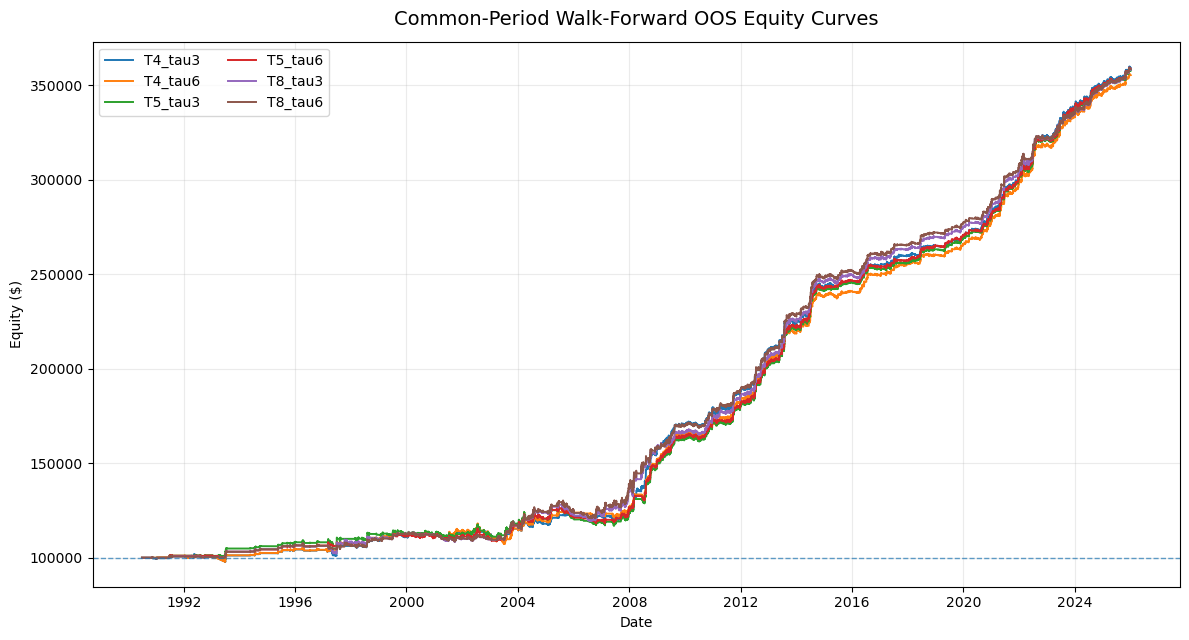

In [22]:
# ============================================================
# 6.1 COMMON-PERIOD OOS EQUITY CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6.5)
)


for spec in spec_order:

    path = (
        common_oos_paths[
            spec
        ]
    )

    ax.plot(
        path["ts"],
        path["equity"],
        linewidth=1.4,
        label=spec
    )


# ------------------------------------------------------------
# Reference line
# ------------------------------------------------------------

ax.axhline(
    INITIAL_EQUITY,
    linewidth=1.0,
    linestyle="--",
    alpha=0.7
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    "Common-Period Walk-Forward OOS Equity Curves",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Equity ($)"
)


ax.legend(
    loc="upper left",
    frameon=True,
    ncol=2
)


ax.grid(
    alpha=0.25
)


plt.tight_layout()
plt.show()

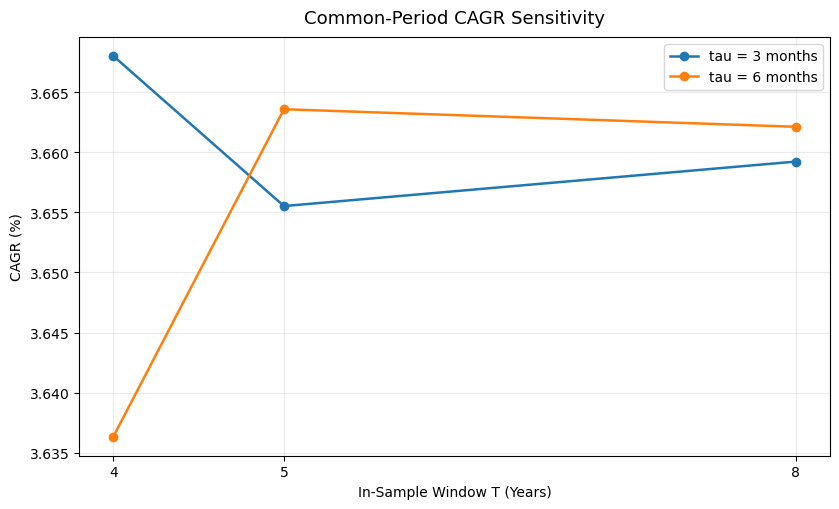

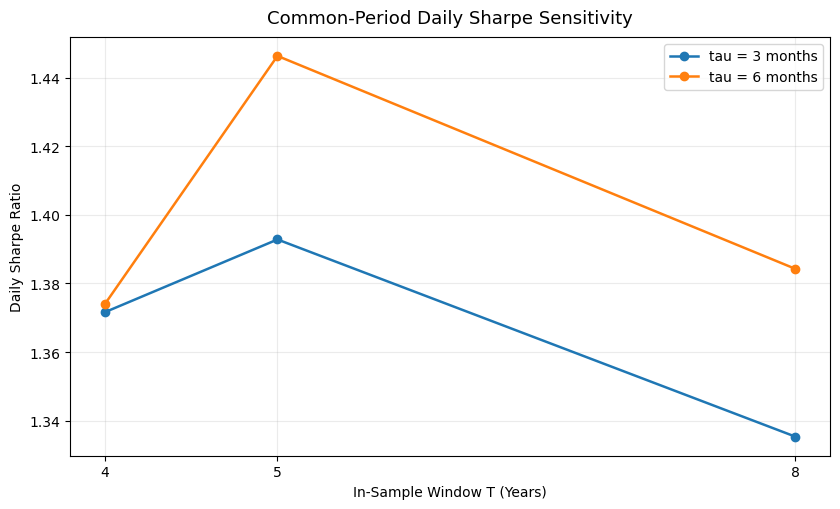

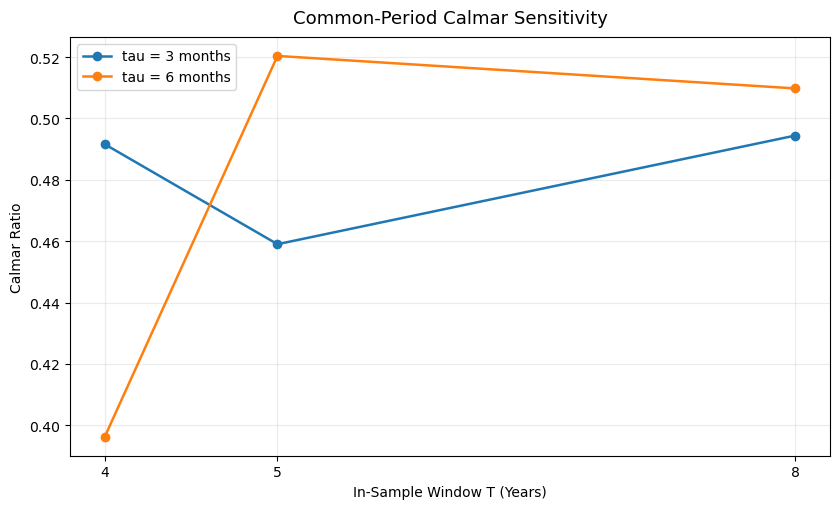

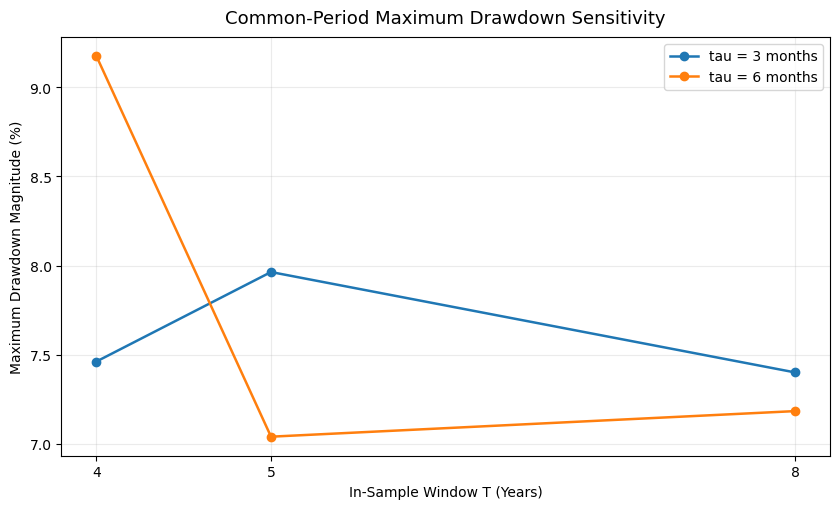

In [23]:
# ============================================================
# 6.2 COMMON-PERIOD PERFORMANCE SENSITIVITY
# ============================================================

performance_plot_data = (
    common_period_summary.copy()
)


performance_plot_data[
    "T"
] = (
    performance_plot_data[
        "Specification"
    ]
    .str.extract(
        r"T(\d+)"
    )[0]
    .astype(int)
)


performance_plot_data[
    "tau"
] = (
    performance_plot_data[
        "Specification"
    ]
    .str.extract(
        r"tau(\d+)"
    )[0]
    .astype(int)
)


# ============================================================
# FIGURE 1 — CAGR
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)


for tau in [3, 6]:

    subset = (
        performance_plot_data[
            performance_plot_data[
                "tau"
            ] == tau
        ]
        .sort_values(
            "T"
        )
    )

    ax.plot(
        subset["T"],
        subset["CAGR"] * 100,
        marker="o",
        linewidth=1.8,
        label=f"tau = {tau} months"
    )


ax.set_title(
    "Common-Period CAGR Sensitivity",
    fontsize=13,
    pad=10
)

ax.set_xlabel(
    "In-Sample Window T (Years)"
)

ax.set_ylabel(
    "CAGR (%)"
)

ax.set_xticks(
    [4, 5, 8]
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — DAILY SHARPE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)


for tau in [3, 6]:

    subset = (
        performance_plot_data[
            performance_plot_data[
                "tau"
            ] == tau
        ]
        .sort_values(
            "T"
        )
    )

    ax.plot(
        subset["T"],
        subset["Daily_Sharpe"],
        marker="o",
        linewidth=1.8,
        label=f"tau = {tau} months"
    )


ax.set_title(
    "Common-Period Daily Sharpe Sensitivity",
    fontsize=13,
    pad=10
)

ax.set_xlabel(
    "In-Sample Window T (Years)"
)

ax.set_ylabel(
    "Daily Sharpe Ratio"
)

ax.set_xticks(
    [4, 5, 8]
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — CALMAR
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)


for tau in [3, 6]:

    subset = (
        performance_plot_data[
            performance_plot_data[
                "tau"
            ] == tau
        ]
        .sort_values(
            "T"
        )
    )

    ax.plot(
        subset["T"],
        subset["Calmar"],
        marker="o",
        linewidth=1.8,
        label=f"tau = {tau} months"
    )


ax.set_title(
    "Common-Period Calmar Sensitivity",
    fontsize=13,
    pad=10
)

ax.set_xlabel(
    "In-Sample Window T (Years)"
)

ax.set_ylabel(
    "Calmar Ratio"
)

ax.set_xticks(
    [4, 5, 8]
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 4 — MAXIMUM DRAWDOWN
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)


for tau in [3, 6]:

    subset = (
        performance_plot_data[
            performance_plot_data[
                "tau"
            ] == tau
        ]
        .sort_values(
            "T"
        )
    )

    ax.plot(
        subset["T"],
        abs(
            subset["MaxDD_Pct"]
        ) * 100,
        marker="o",
        linewidth=1.8,
        label=f"tau = {tau} months"
    )


ax.set_title(
    "Common-Period Maximum Drawdown Sensitivity",
    fontsize=13,
    pad=10
)

ax.set_xlabel(
    "In-Sample Window T (Years)"
)

ax.set_ylabel(
    "Maximum Drawdown Magnitude (%)"
)

ax.set_xticks(
    [4, 5, 8]
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

### 6.3 Parameter Selection Sensitivity

The selected strategy parameters are also compared across walk-forward
specifications. This analysis distinguishes performance robustness from
parameter stability and highlights whether the optimizer repeatedly selects
the boundaries of the prescribed search grid.

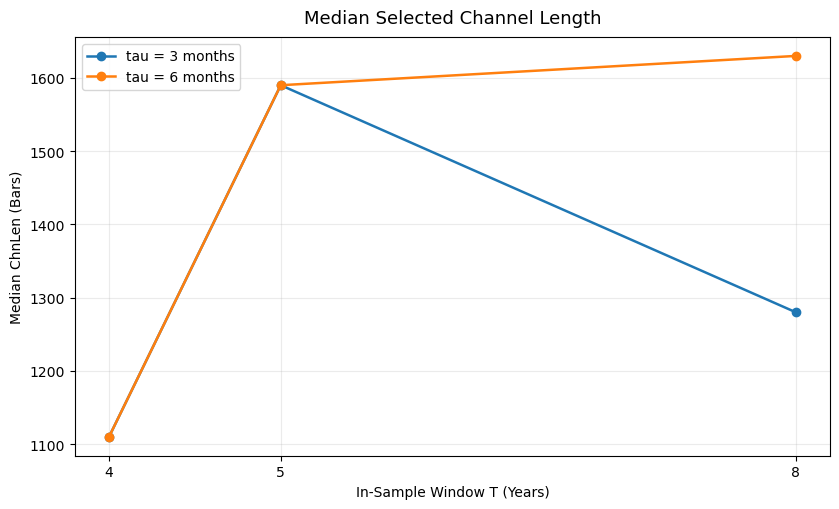

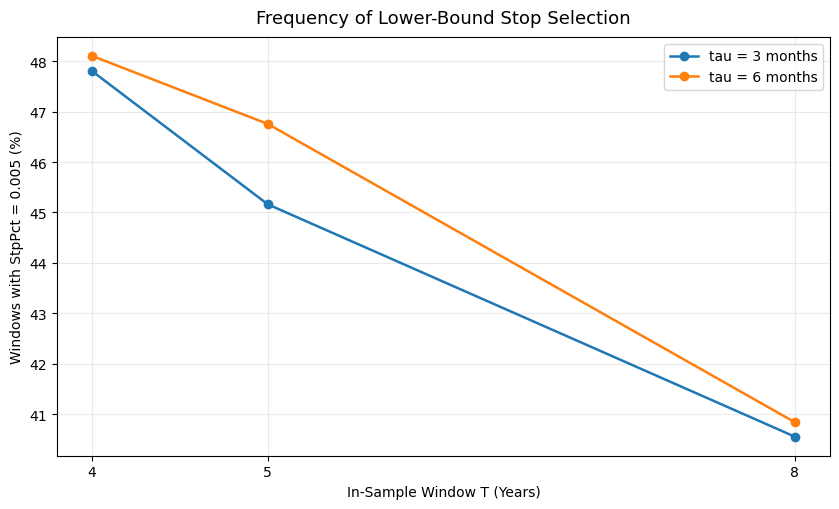

In [24]:
# ------------------------------------------------------------
# Prepare plotting data
# ------------------------------------------------------------

parameter_plot_data = (
    parameter_stability.copy()
)


# ============================================================
# FIGURE 1 — CHANNEL LENGTH
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)


for tau in [3, 6]:

    subset = (
        parameter_plot_data[
            parameter_plot_data[
                "tau (Months)"
            ] == tau
        ]
        .sort_values(
            "T (Years)"
        )
    )

    ax.plot(
        subset["T (Years)"],
        subset["ChnLen_Median"],
        marker="o",
        linewidth=1.8,
        label=f"tau = {tau} months"
    )


ax.set_title(
    "Median Selected Channel Length",
    fontsize=13,
    pad=10
)

ax.set_xlabel(
    "In-Sample Window T (Years)"
)

ax.set_ylabel(
    "Median ChnLen (Bars)"
)

ax.set_xticks(
    [4, 5, 8]
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — STOP-PERCENTAGE LOWER-BOUND FREQUENCY
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)


for tau in [3, 6]:

    subset = (
        parameter_plot_data[
            parameter_plot_data[
                "tau (Months)"
            ] == tau
        ]
        .sort_values(
            "T (Years)"
        )
    )

    ax.plot(
        subset["T (Years)"],
        subset["StpPct_Lower_Bound_Freq"] * 100,
        marker="o",
        linewidth=1.8,
        label=f"tau = {tau} months"
    )


ax.set_title(
    "Frequency of Lower-Bound Stop Selection",
    fontsize=13,
    pad=10
)

ax.set_xlabel(
    "In-Sample Window T (Years)"
)

ax.set_ylabel(
    "Windows with StpPct = 0.005 (%)"
)

ax.set_xticks(
    [4, 5, 8]
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

## 7. Final Robustness Validation

Before drawing conclusions, the sensitivity analysis is checked for internal
consistency. The validation confirms that all six specifications use the
prescribed parameter grid, produce complete and chronologically ordered OOS
paths, and are compared over an identical common evaluation period.

In [25]:
validation_rows = []


for spec in spec_order:

    result = all_results[spec]

    params = (
        result["parameters"]
        .copy()
    )

    oos = (
        result["oos"]
        .copy()
    )

    common_path = (
        common_oos_paths[spec]
        .copy()
    )


    # --------------------------------------------------------
    # Parameter-grid checks
    # --------------------------------------------------------

    chn_values = (
        params["ChnLen"]
        .to_numpy(dtype=float)
    )

    stp_values = (
        params["StpPct"]
        .to_numpy(dtype=float)
    )


    chn_in_grid = bool(
        np.all(
            np.isin(
                chn_values,
                CHNLEN_RANGE
            )
        )
    )


    stp_in_grid = bool(
        np.all(
            [
                np.any(
                    np.isclose(
                        STPPCT_RANGE,
                        x
                    )
                )
                for x in stp_values
            ]
        )
    )


    # --------------------------------------------------------
    # OOS-path checks
    # --------------------------------------------------------

    no_duplicate_oos = bool(
        oos["ts"]
        .duplicated()
        .sum()
        == 0
    )


    chronological_oos = bool(
        oos["ts"]
        .is_monotonic_increasing
    )


    finite_oos_pnl = bool(
        np.isfinite(
            oos["bar_pnl"]
            .to_numpy(dtype=float)
        )
        .all()
    )


    # --------------------------------------------------------
    # Common-period checks
    # --------------------------------------------------------

    common_first_match = bool(
        common_path["ts"].iloc[0]
        ==
        common_start
    )


    common_last_match = bool(
        common_path["ts"].iloc[-1]
        ==
        common_end
    )


    common_bar_count_match = bool(
        len(common_path)
        ==
        len(
            common_oos_paths[
                spec_order[0]
            ]
        )
    )


    # --------------------------------------------------------
    # Common-period accounting reconciliation
    # --------------------------------------------------------

    common_perf = (
        common_period_summary.loc[
            common_period_summary[
                "Specification"
            ] == spec
        ]
        .iloc[0]
    )


    pnl_sum = float(
        common_path[
            "bar_pnl"
        ].sum()
    )


    reported_net_profit = float(
        common_perf[
            "Net_Profit"
        ]
    )


    accounting_error = (
        pnl_sum
        -
        reported_net_profit
    )


    accounting_reconciles = bool(
        np.isclose(
            pnl_sum,
            reported_net_profit,
            atol=1e-6
        )
    )


    # --------------------------------------------------------
    # Collect
    # --------------------------------------------------------

    validation_rows.append(
        {
            "Specification":
                spec,

            "ChnLen In Grid":
                chn_in_grid,

            "StpPct In Grid":
                stp_in_grid,

            "No Duplicate OOS Timestamps":
                no_duplicate_oos,

            "Chronological OOS":
                chronological_oos,

            "Finite OOS P&L":
                finite_oos_pnl,

            "Common Start Match":
                common_first_match,

            "Common End Match":
                common_last_match,

            "Common Bar Count Match":
                common_bar_count_match,

            "Accounting Error":
                accounting_error,

            "Accounting Reconciles":
                accounting_reconciles
        }
    )


final_validation = pd.DataFrame(
    validation_rows
)


print(
    "FINAL TASK 8 ROBUSTNESS VALIDATION"
)

print(
    "=" * 100
)

display(
    final_validation
)


# ============================================================
# OVERALL CHECK
# ============================================================

boolean_columns = [
    "ChnLen In Grid",
    "StpPct In Grid",
    "No Duplicate OOS Timestamps",
    "Chronological OOS",
    "Finite OOS P&L",
    "Common Start Match",
    "Common End Match",
    "Common Bar Count Match",
    "Accounting Reconciles"
]


all_checks_pass = bool(
    final_validation[
        boolean_columns
    ]
    .to_numpy()
    .all()
)


max_abs_accounting_error = float(
    final_validation[
        "Accounting Error"
    ]
    .abs()
    .max()
)


print()

print(
    f"All Task 8 validation checks passed: "
    f"{all_checks_pass}"
)

print(
    f"Maximum absolute accounting error: "
    f"{max_abs_accounting_error:.12f}"
)

FINAL TASK 8 ROBUSTNESS VALIDATION


,Specification,ChnLen In Grid,StpPct In Grid,No Duplicate OOS Timestamps,Chronological OOS,Finite OOS P&L,Common Start Match,Common End Match,Common Bar Count Match,Accounting Error,Accounting Reconciles
0,T4_tau3,True,True,True,True,True,True,True,True,9.895302e-10,True
1,T4_tau6,True,True,True,True,True,True,True,True,1.047738e-09,True
2,T5_tau3,True,True,True,True,True,True,True,True,6.693881e-10,True
3,T5_tau6,True,True,True,True,True,True,True,True,8.149073e-10,True
4,T8_tau3,True,True,True,True,True,True,True,True,9.313226e-10,True
5,T8_tau6,True,True,True,True,True,True,True,True,9.604264e-10,True



All Task 8 validation checks passed: True
Maximum absolute accounting error: 0.000000001048


## 8. Final Findings and Interpretation

### 8.1 Performance Robustness

The baseline specification from Task 5 uses a 4-year in-sample window and a
3-month OOS horizon. To test whether its results depend materially on this
particular walk-forward design, six specifications were evaluated using
\(T \in \{4,5,8\}\) years and \(\tau \in \{3,6\}\) months while keeping the
strategy logic, transaction costs, parameter grid, optimization objective, and
IS-conditioned OOS evaluation procedure unchanged.

Because different values of \(T\) and \(\tau\) generate different available OOS
histories, the primary robustness comparison uses the common OOS period from
1990-07-02 through 2025-12-31. Each specification contains the same 401,600
5-minute OOS bars over this interval and is rebased to an initial equity of
$100,000.

Performance is highly consistent across the six specifications. Common-period
CAGR ranges only from approximately 3.64% to 3.67%, while the Daily Sharpe
Ratio remains between approximately 1.34 and 1.45. The six equity curves also
follow closely aligned long-run trajectories, with major periods of gains,
stagnation, and drawdowns occurring broadly together. Therefore, the historical
OOS return generation does not appear to be driven by a single choice of
in-sample window \(T\) or re-optimization horizon \(\tau\).

### 8.2 Risk Sensitivity

Risk-adjusted performance shows somewhat greater variation than CAGR. The
common-period maximum drawdown ranges from approximately -7.04% to -9.18%,
and the Calmar Ratio ranges from approximately 0.40 to 0.52.

This indicates that the walk-forward design has a greater effect on the timing
and magnitude of drawdowns than on long-run return generation. In particular,
some specifications experience deeper temporary losses even though their
long-run CAGR and Sharpe Ratio remain similar.

Accordingly, the sensitivity results support robustness in the strategy's
historical return-generating behavior while also showing that its realized
drawdown profile is moderately sensitive to the walk-forward configuration.

### 8.3 Parameter Stability

The optimized parameters are not constant across walk-forward specifications.
Median selected channel lengths range from approximately 1,110 to 1,630 bars,
indicating that the estimated trend horizon changes with the amount of
in-sample information and the re-optimization frequency.

However, the channel-length parameter shows little evidence of grid-boundary
dependence. Selection of the minimum channel length of 500 bars is infrequent,
and the maximum value of 10,000 bars is never selected in the tested
specifications.

The stop parameter exhibits a clearer boundary effect. The median selected
StpPct is 0.006 under all six specifications, while approximately 41% to 48% of
optimization windows select the prescribed lower bound of 0.005. The frequency
of lower-bound selection generally decreases as the in-sample window becomes
longer, but remains economically meaningful even for the 8-year specifications.

This lower-bound clustering is therefore retained as an explicit robustness
caveat. The parameter grid is not expanded because the sensitivity exercise is
intended to evaluate the professor-specified strategy and search space rather
than redesign the optimization problem ex post.

### 8.4 Overall Interpretation

The sensitivity analysis provides evidence that the main Task 5 walk-forward
conclusion is not uniquely dependent on the baseline choice of a 4-year
in-sample window and a 3-month OOS horizon. Across reasonable alternative
values of \(T\) and \(\tau\), the strategy remains profitable over the common
historical OOS period, with closely aligned equity trajectories and highly
similar long-run growth rates.

At the same time, the analysis does not imply that all walk-forward
configurations are equivalent. Drawdown characteristics vary more noticeably,
optimized channel lengths remain regime-dependent, and the stop parameter
frequently reaches the lower boundary of the prescribed grid.

No alternative \(T,\tau\) specification is selected as a new "optimal"
configuration. Doing so based on the same historical sensitivity results would
introduce an additional layer of data snooping. Instead, Task 8 is interpreted
as a robustness check on the baseline design.

Overall, the results strengthen the historical evidence supporting the Task 5
walk-forward findings, while the drawdown sensitivity and lower-bound stop
selection remain important limitations. These results describe historical
robustness and do not guarantee similar performance in future market regimes.

In [27]:
final_summary = pd.DataFrame(
    {
        "Dimension": [
            "Common OOS Period",
            "Common OOS Bars",
            "CAGR Range",
            "Daily Sharpe Range",
            "Maximum Drawdown Range",
            "Calmar Range",
            "Median ChnLen Range",
            "Median StpPct",
            "StpPct=0.005 Frequency",
            "Overall Assessment"
        ],

        "Result": [
            "1990-07-02 to 2025-12-31",
            "401,600 per specification",
            (
                f"{common_period_summary['CAGR'].min():.2%}"
                f" to "
                f"{common_period_summary['CAGR'].max():.2%}"
            ),
            (
                f"{common_period_summary['Daily_Sharpe'].min():.4f}"
                f" to "
                f"{common_period_summary['Daily_Sharpe'].max():.4f}"
            ),
            (
                f"{common_period_summary['MaxDD_Pct'].min():.2%}"
                f" to "
                f"{common_period_summary['MaxDD_Pct'].max():.2%}"
            ),
            (
                f"{common_period_summary['Calmar'].min():.4f}"
                f" to "
                f"{common_period_summary['Calmar'].max():.4f}"
            ),
            (
                f"{parameter_stability['ChnLen_Median'].min():.0f}"
                f" to "
                f"{parameter_stability['ChnLen_Median'].max():.0f}"
                f" bars"
            ),
            (
                f"{parameter_stability['StpPct_Median'].min():.3f}"
                f" across all specifications"
            ),
            (
                f"{parameter_stability['StpPct_Lower_Bound_Freq'].min():.2%}"
                f" to "
                f"{parameter_stability['StpPct_Lower_Bound_Freq'].max():.2%}"
            ),
            (
                "Robust across tested T/tau; "
                "risk sensitivity remains."
            )
        ]
    }
)


print(
    "FINAL TASK 8 SENSITIVITY SUMMARY"
)

print(
    "=" * 90
)

display(
    final_summary
)

FINAL TASK 8 SENSITIVITY SUMMARY


,Dimension,Result
0,Common OOS Period,1990-07-02 to 2025-12-31
1,Common OOS Bars,"401,600 per specification"
2,CAGR Range,3.64% to 3.67%
3,Daily Sharpe Range,1.3353 to 1.4464
4,Maximum Drawdown Range,-9.18% to -7.04%
5,Calmar Range,0.3963 to 0.5204
6,Median ChnLen Range,1110 to 1630 bars
7,Median StpPct,0.006 across all specifications
8,StpPct=0.005 Frequency,40.56% to 48.10%
9,Overall Assessment,Robust across tested T/tau; risk sensitivity r...
